# Covid 19 Trend Analysis Project

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
df=pd.read_csv('covid_19_data.csv')

In [10]:
df.head(10)

,SNo,ObservationDate,Province/State,Country/Region,Last Update,Confirmed,Deaths,Recovered
0,1,1/22/2020,Anhui,Mainland China,1/22/2020 17:00,1,0,0
1,2,1/22/2020,Beijing,Mainland China,1/22/2020 17:00,14,0,0
2,3,1/22/2020,Chongqing,Mainland China,1/22/2020 17:00,6,0,0
3,4,1/22/2020,Fujian,Mainland China,1/22/2020 17:00,1,0,0
4,5,1/22/2020,Gansu,Mainland China,1/22/2020 17:00,0,0,0
5,6,1/22/2020,Guangdong,Mainland China,1/22/2020 17:00,26,0,0
6,7,1/22/2020,Guangxi,Mainland China,1/22/2020 17:00,2,0,0
7,8,1/22/2020,Guizhou,Mainland China,1/22/2020 17:00,1,0,0
8,9,1/22/2020,Hainan,Mainland China,1/22/2020 17:00,4,0,0
9,10,1/22/2020,Hebei,Mainland China,1/22/2020 17:00,1,0,0


In [11]:
df.drop(['SNo','Last Update'],axis=1,inplace=True)

In [12]:
df.head(10)

,ObservationDate,Province/State,Country/Region,Confirmed,Deaths,Recovered
0,1/22/2020,Anhui,Mainland China,1,0,0
1,1/22/2020,Beijing,Mainland China,14,0,0
2,1/22/2020,Chongqing,Mainland China,6,0,0
3,1/22/2020,Fujian,Mainland China,1,0,0
4,1/22/2020,Gansu,Mainland China,0,0,0
5,1/22/2020,Guangdong,Mainland China,26,0,0
6,1/22/2020,Guangxi,Mainland China,2,0,0
7,1/22/2020,Guizhou,Mainland China,1,0,0
8,1/22/2020,Hainan,Mainland China,4,0,0
9,1/22/2020,Hebei,Mainland China,1,0,0


In [13]:
df=df.rename(columns={'ObservationDate':'Date','Province/State':'Province','Country/Region':'Country'})

In [14]:
df.head(10)

,Date,Province,Country,Confirmed,Deaths,Recovered
0,1/22/2020,Anhui,Mainland China,1,0,0
1,1/22/2020,Beijing,Mainland China,14,0,0
2,1/22/2020,Chongqing,Mainland China,6,0,0
3,1/22/2020,Fujian,Mainland China,1,0,0
4,1/22/2020,Gansu,Mainland China,0,0,0
5,1/22/2020,Guangdong,Mainland China,26,0,0
6,1/22/2020,Guangxi,Mainland China,2,0,0
7,1/22/2020,Guizhou,Mainland China,1,0,0
8,1/22/2020,Hainan,Mainland China,4,0,0
9,1/22/2020,Hebei,Mainland China,1,0,0


In [15]:
df['Date']=pd.to_datetime(df['Date'])

In [16]:
df.head()

,Date,Province,Country,Confirmed,Deaths,Recovered
0,2020-01-22,Anhui,Mainland China,1,0,0
1,2020-01-22,Beijing,Mainland China,14,0,0
2,2020-01-22,Chongqing,Mainland China,6,0,0
3,2020-01-22,Fujian,Mainland China,1,0,0
4,2020-01-22,Gansu,Mainland China,0,0,0


In [17]:
df.describe()

,Confirmed,Deaths,Recovered
count,6162.000000,6162.000000,6162.000000
mean,588.957481,18.960240,220.271503
std,4908.724815,198.962911,2466.089672
min,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000
75%,100.000000,1.000000,12.000000
max,67798.000000,3099.000000,55142.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6162 entries, 0 to 6161
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6162 non-null   datetime64[ns]
 1   Province   3700 non-null   object        
 2   Country    6162 non-null   object        
 3   Confirmed  6162 non-null   int64         
 4   Deaths     6162 non-null   int64         
 5   Recovered  6162 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 289.0+ KB


In [19]:
df.fillna('Na')

,Date,Province,Country,Confirmed,Deaths,Recovered
0,2020-01-22,Anhui,Mainland China,1,0,0
1,2020-01-22,Beijing,Mainland China,14,0,0
2,2020-01-22,Chongqing,Mainland China,6,0,0
3,2020-01-22,Fujian,Mainland China,1,0,0
4,2020-01-22,Gansu,Mainland China,0,0,0
...,...,...,...,...,...,...
6157,2020-03-16,Cayman Islands,UK,1,1,0
6158,2020-03-16,Gibraltar,UK,1,0,1
6159,2020-03-16,Diamond Princess cruise ship,Australia,0,0,0
6160,2020-03-16,West Virginia,US,0,0,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6162 entries, 0 to 6161
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6162 non-null   datetime64[ns]
 1   Province   3700 non-null   object        
 2   Country    6162 non-null   object        
 3   Confirmed  6162 non-null   int64         
 4   Deaths     6162 non-null   int64         
 5   Recovered  6162 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 289.0+ KB


In [21]:
 df2=df.groupby('Country')[['Country','Confirmed','Deaths','Recovered']].sum().reset_index()

/var/folders/w3/ktvr1fsx4vzf522j4ttzycj40000gn/T/ipykernel_44874/312775282.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df2=df.groupby('Country')[['Country','Confirmed','Deaths','Recovered']].sum().reset_index()


In [22]:
df2

,Country,Confirmed,Deaths,Recovered
0,Azerbaijan,1,0,0
1,"('St. Martin',)",2,0,0
2,Afghanistan,95,0,1
3,Albania,211,6,0
4,Algeria,340,14,52
...,...,...,...,...
166,Uzbekistan,7,0,0
167,Vatican City,4,0,0
168,Venezuela,29,0,0
169,Vietnam,915,0,470


In [23]:
 df2=df.groupby(['Country','Date'])[['Country','Date','Confirmed','Deaths','Recovered']].sum().reset_index()

/var/folders/w3/ktvr1fsx4vzf522j4ttzycj40000gn/T/ipykernel_44874/3630882456.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df2=df.groupby(['Country','Date'])[['Country','Date','Confirmed','Deaths','Recovered']].sum().reset_index()


In [24]:
df2

,Country,Date,Confirmed,Deaths,Recovered
0,Azerbaijan,2020-02-28,1,0,0
1,"('St. Martin',)",2020-03-10,2,0,0
2,Afghanistan,2020-02-24,1,0,0
3,Afghanistan,2020-02-25,1,0,0
4,Afghanistan,2020-02-26,1,0,0
...,...,...,...,...,...
2897,occupied Palestinian territory,2020-03-11,0,0,0
2898,occupied Palestinian territory,2020-03-12,0,0,0
2899,occupied Palestinian territory,2020-03-14,0,0,0
2900,occupied Palestinian territory,2020-03-15,0,0,0


In [25]:
df2 = df.groupby(['Country', 'Date'])[['Confirmed', 'Deaths', 'Recovered']].sum(numeric_only=True).reset_index()
df2

,Country,Date,Confirmed,Deaths,Recovered
0,Azerbaijan,2020-02-28,1,0,0
1,"('St. Martin',)",2020-03-10,2,0,0
2,Afghanistan,2020-02-24,1,0,0
3,Afghanistan,2020-02-25,1,0,0
4,Afghanistan,2020-02-26,1,0,0
...,...,...,...,...,...
2897,occupied Palestinian territory,2020-03-11,0,0,0
2898,occupied Palestinian territory,2020-03-12,0,0,0
2899,occupied Palestinian territory,2020-03-14,0,0,0
2900,occupied Palestinian territory,2020-03-15,0,0,0


In [26]:
df3=df2[df2['Confirmed']>100]

In [27]:
df3

,Country,Date,Confirmed,Deaths,Recovered
152,Australia,2020-03-10,107,3,21
153,Australia,2020-03-11,128,3,21
154,Australia,2020-03-12,128,3,21
155,Australia,2020-03-13,200,3,23
156,Australia,2020-03-14,250,3,23
...,...,...,...,...,...
2763,US,2020-03-12,1663,40,12
2764,US,2020-03-13,2179,47,12
2765,US,2020-03-14,2726,54,12
2766,US,2020-03-15,3499,63,12


In [28]:
df4=df.groupby('Country')[['Country','Deaths']].sum(numeric_only=True).reset_index()

In [29]:
df5=df4[df4['Deaths']>10]
df5

,Country,Deaths
4,Algeria,14
7,Argentina,13
10,Australia,40
16,Belgium,22
27,Canada,11
44,Egypt,13
51,France,634
55,Germany,54
58,Greece,14
68,Hong Kong,82


In [30]:
imputer=SimpleImputer(strategy='constant')#SimpleImputer=Tool to fill in missing values
df2=pd.DataFrame(imputer.fit_transform(df),columns=df.columns)

In [31]:
df2

,Date,Province,Country,Confirmed,Deaths,Recovered
0,2020-01-22,Anhui,Mainland China,1,0,0
1,2020-01-22,Beijing,Mainland China,14,0,0
2,2020-01-22,Chongqing,Mainland China,6,0,0
3,2020-01-22,Fujian,Mainland China,1,0,0
4,2020-01-22,Gansu,Mainland China,0,0,0
...,...,...,...,...,...,...
6157,2020-03-16,Cayman Islands,UK,1,1,0
6158,2020-03-16,Gibraltar,UK,1,0,1
6159,2020-03-16,Diamond Princess cruise ship,Australia,0,0,0
6160,2020-03-16,West Virginia,US,0,0,0


In [32]:
countries=df2['Country'].unique()
len(countries)

171

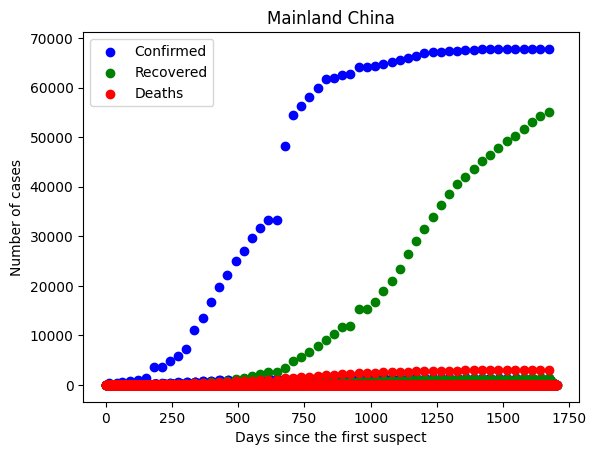

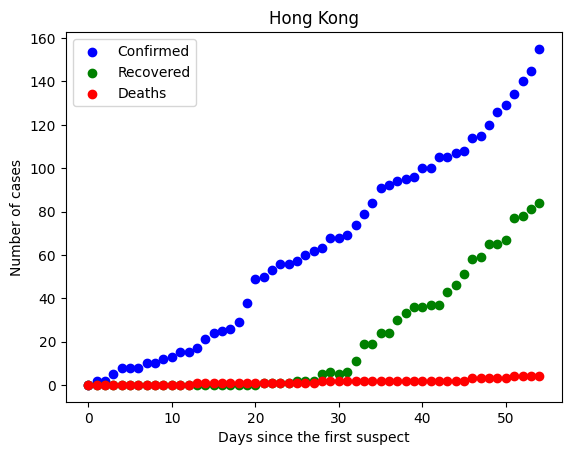

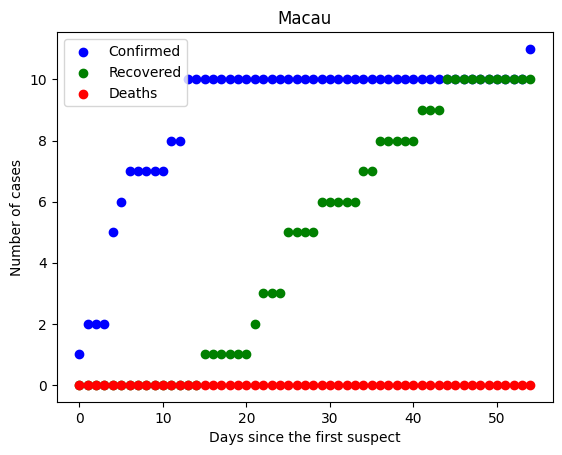

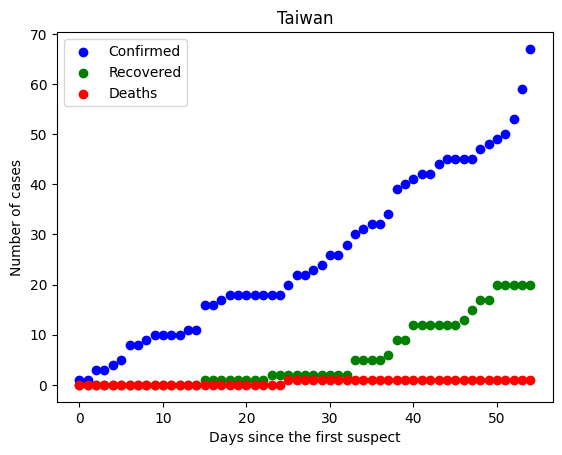

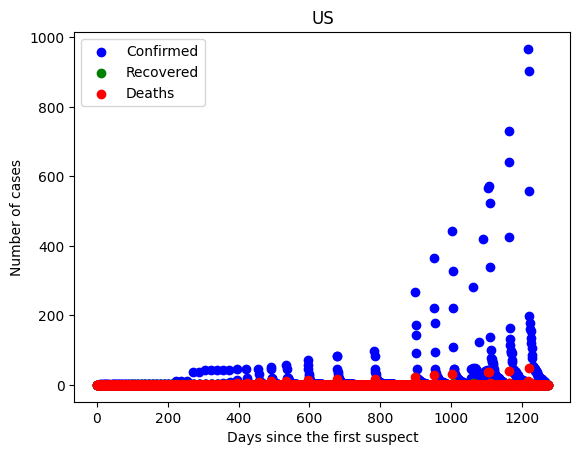

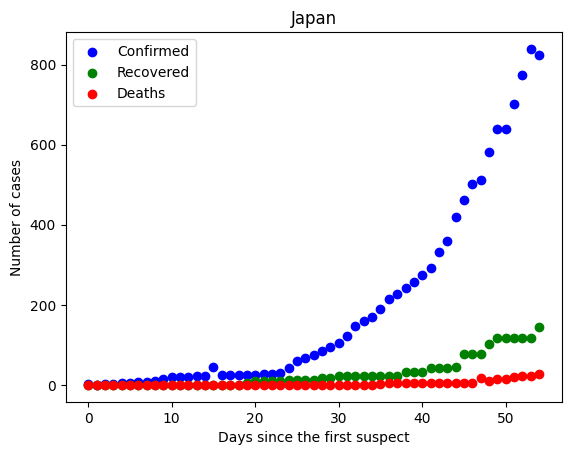

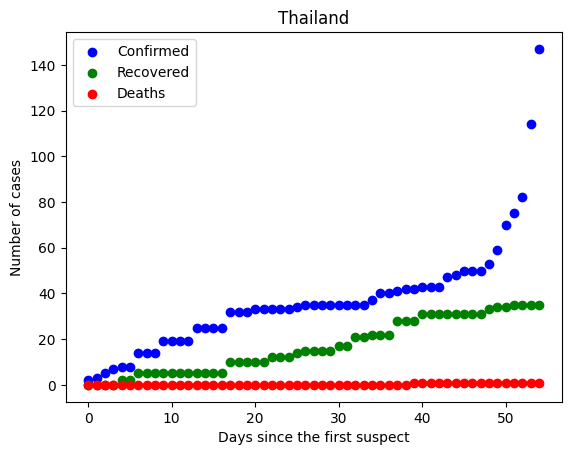

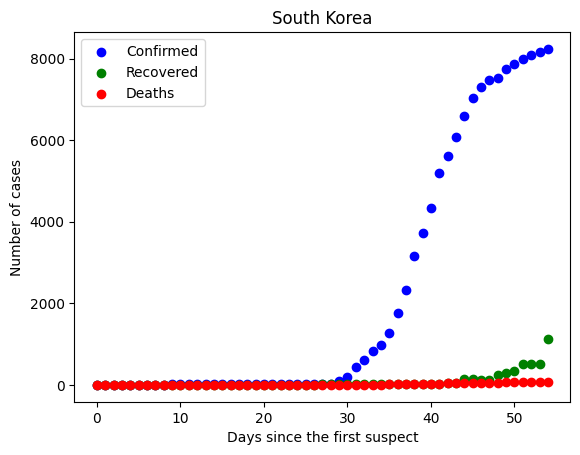

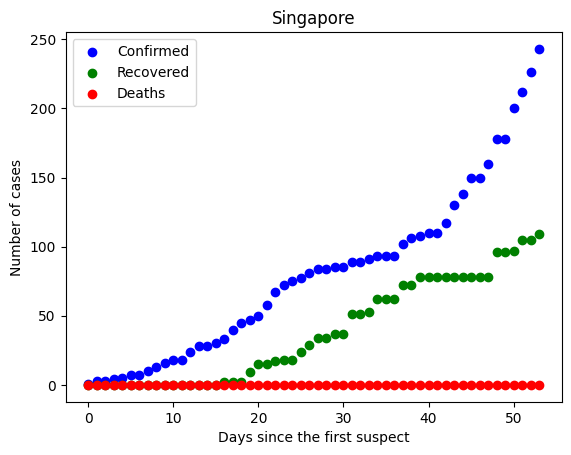

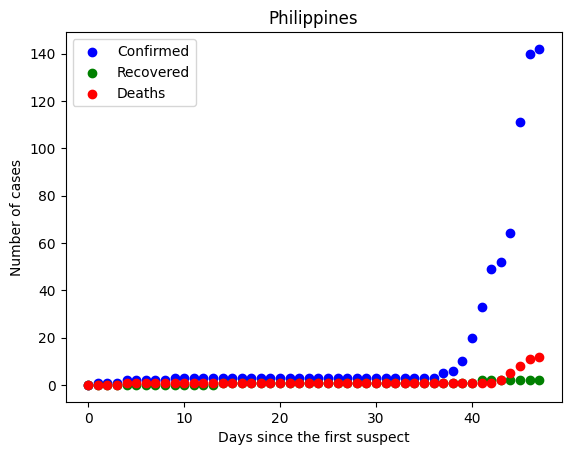

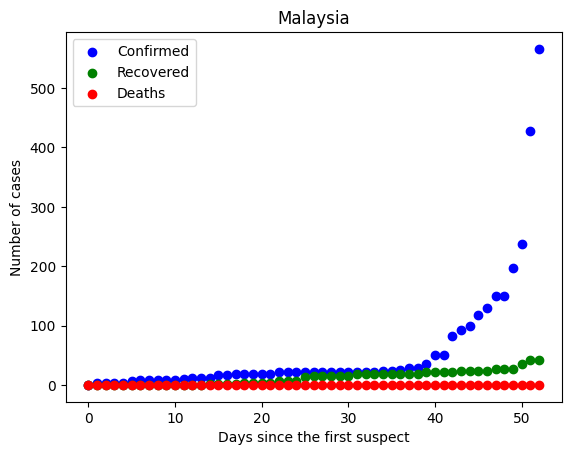

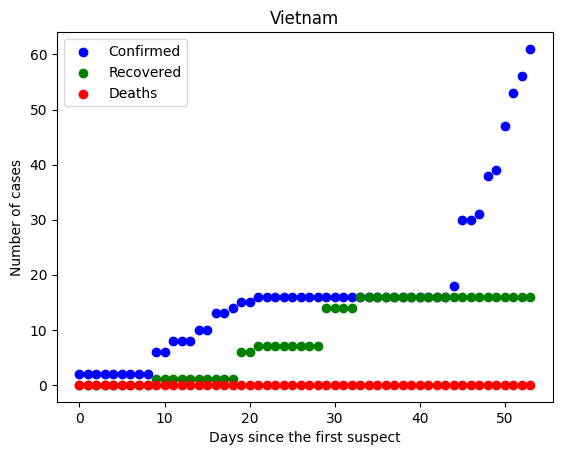

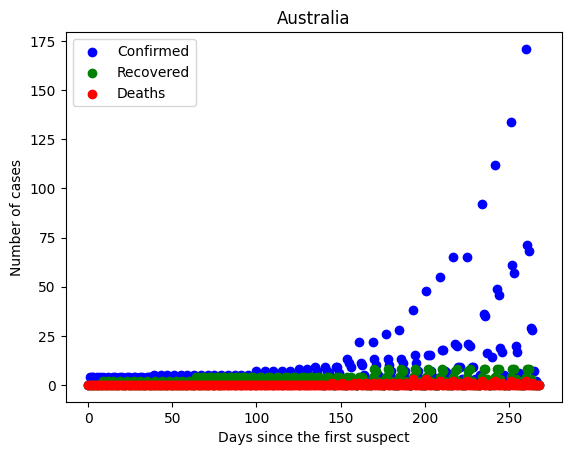

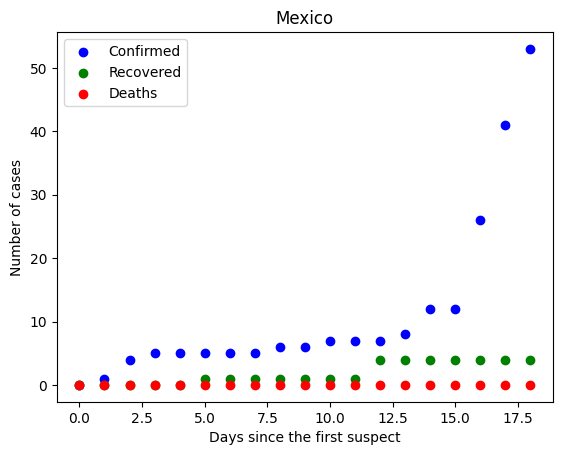

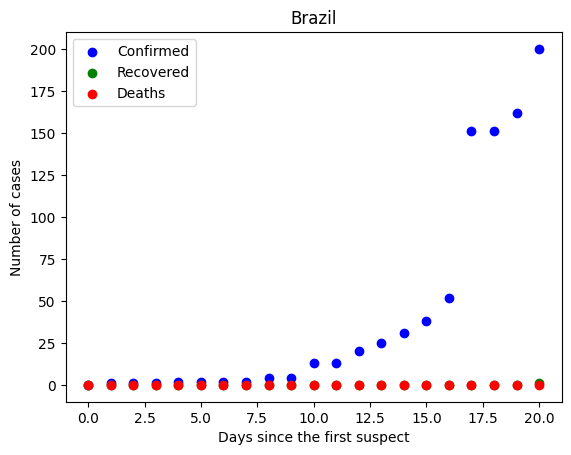

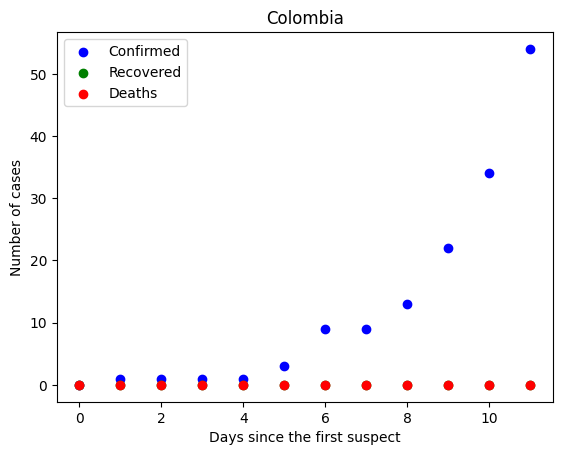

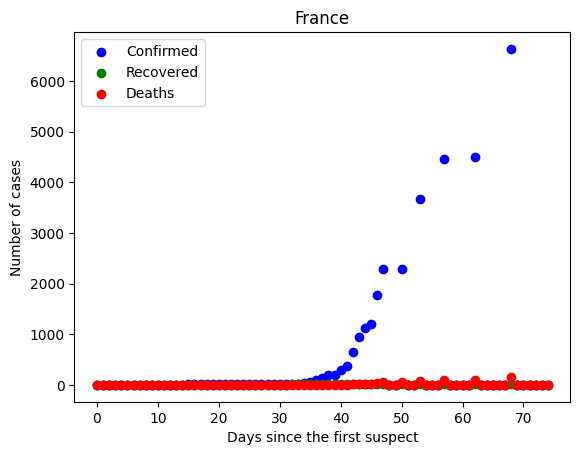

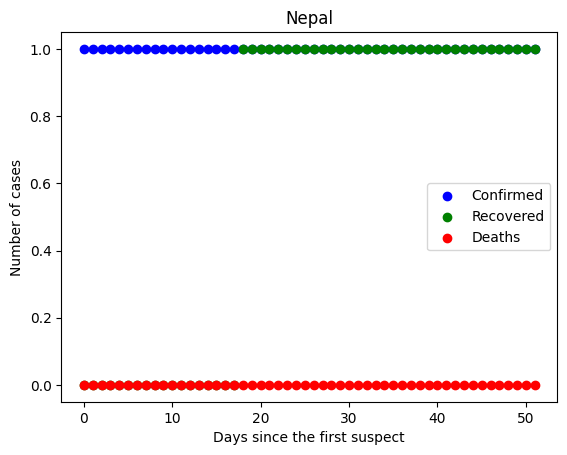

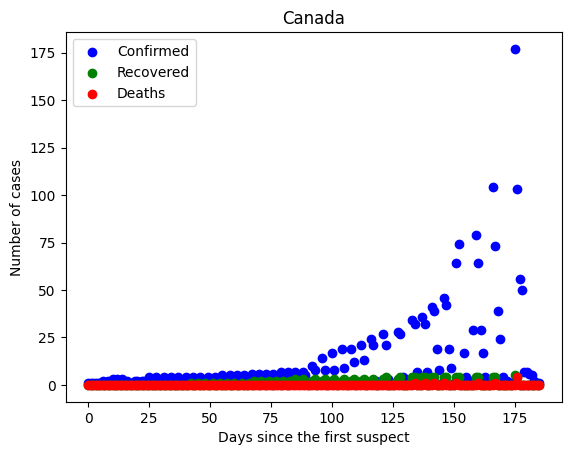

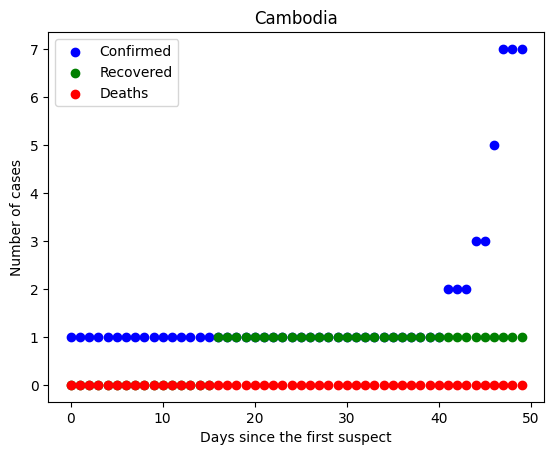

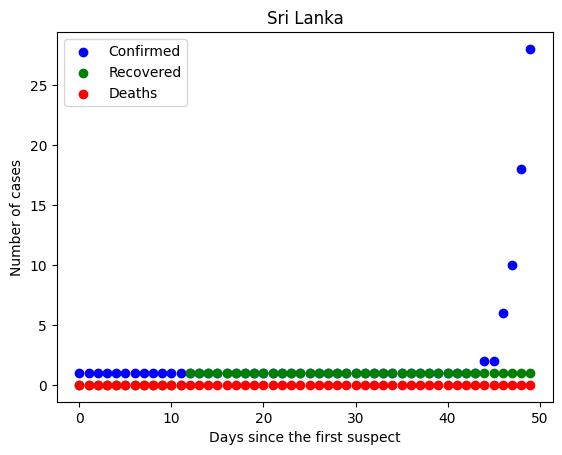

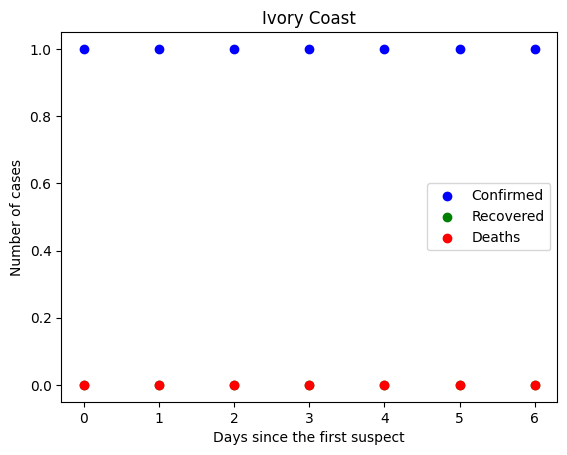

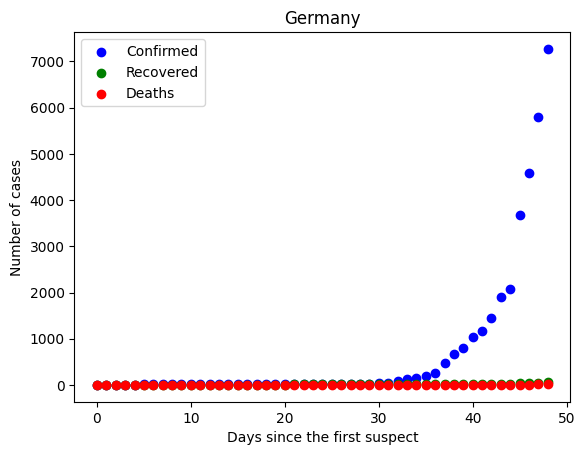

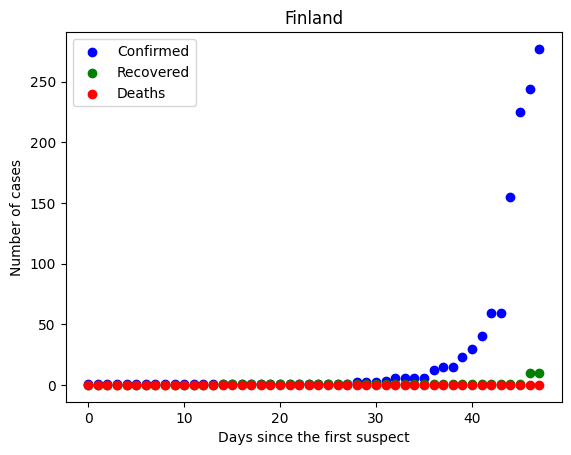

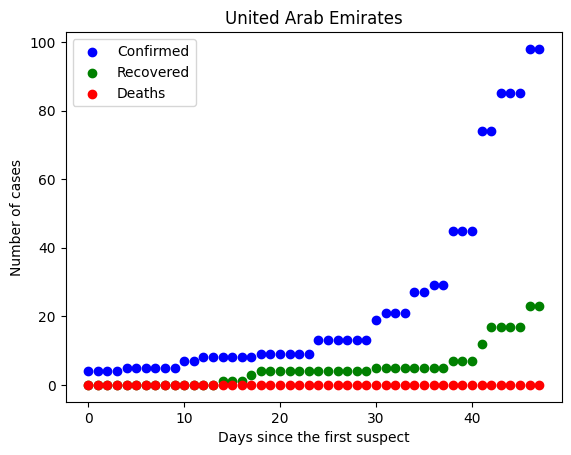

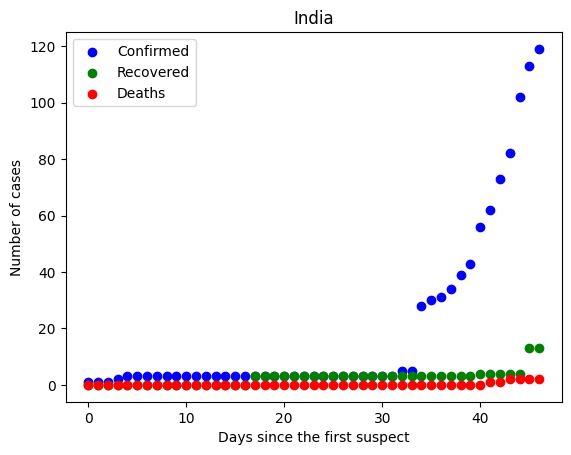

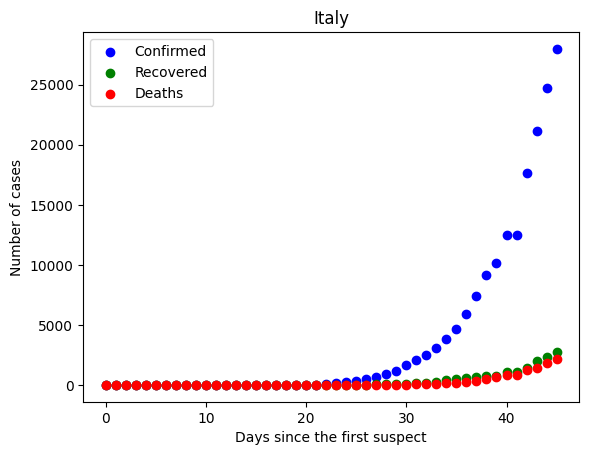

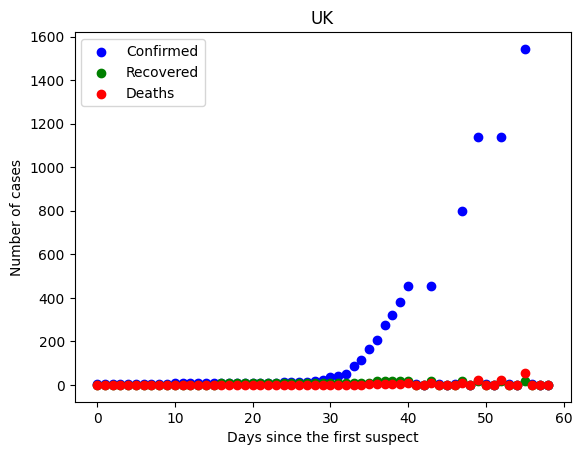

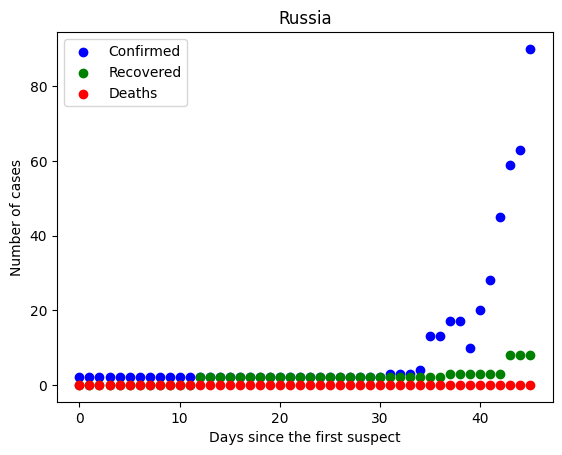

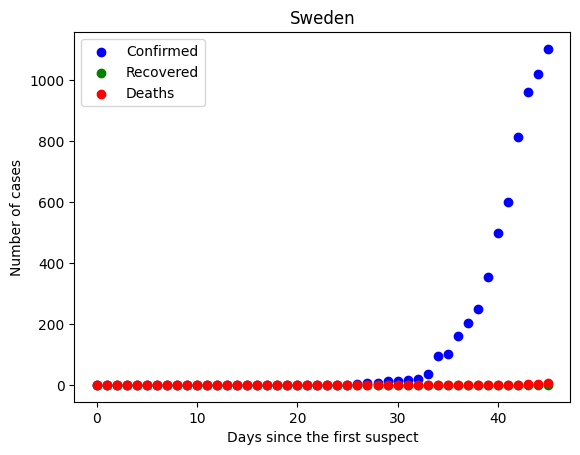

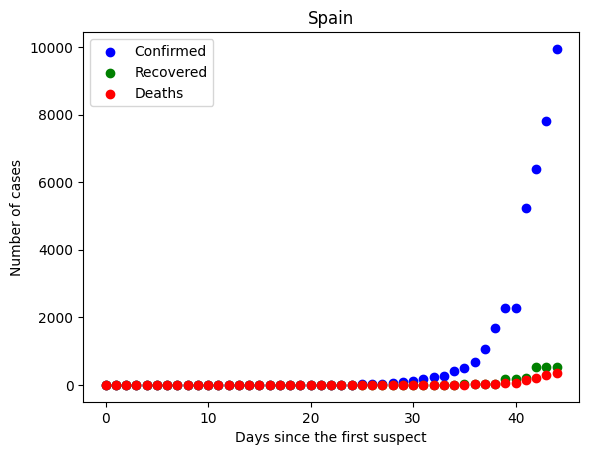

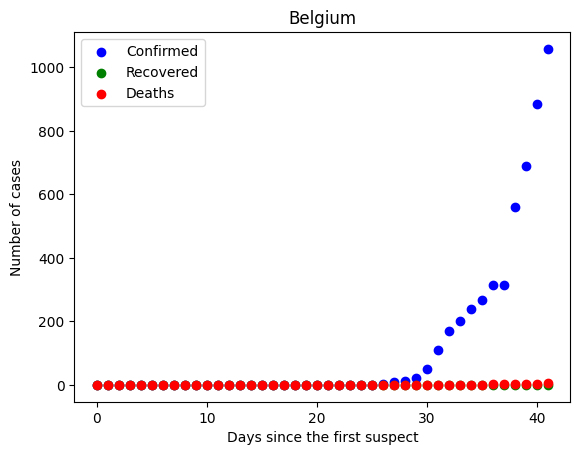

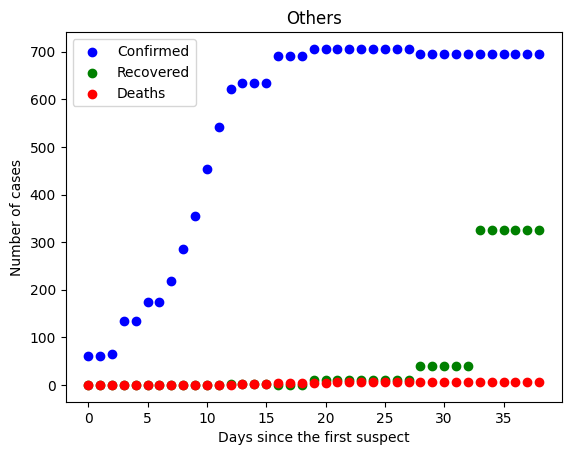

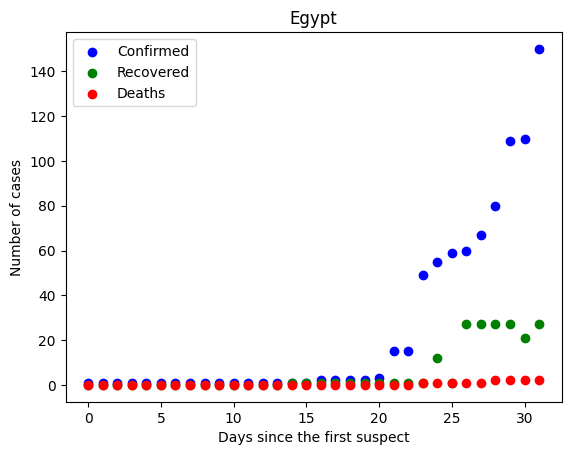

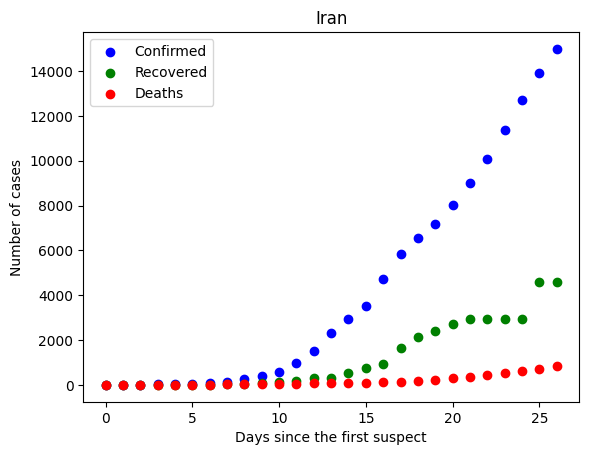

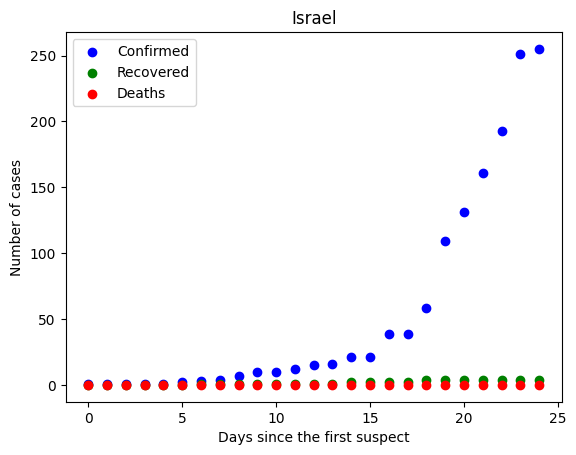

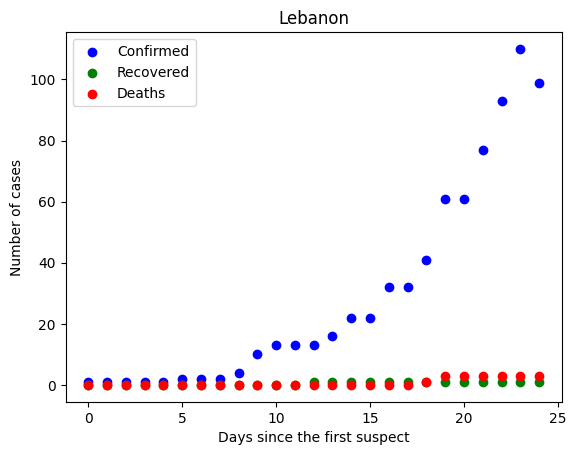

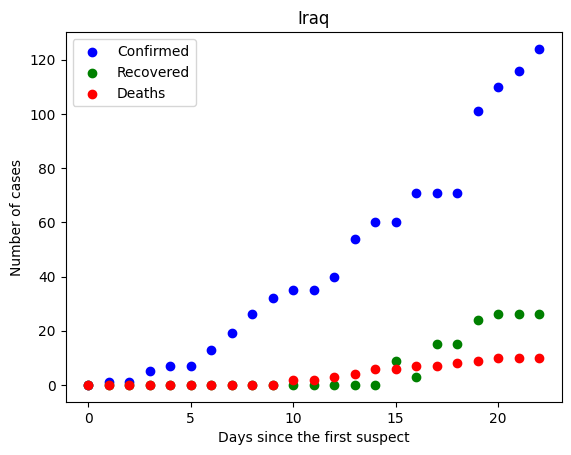

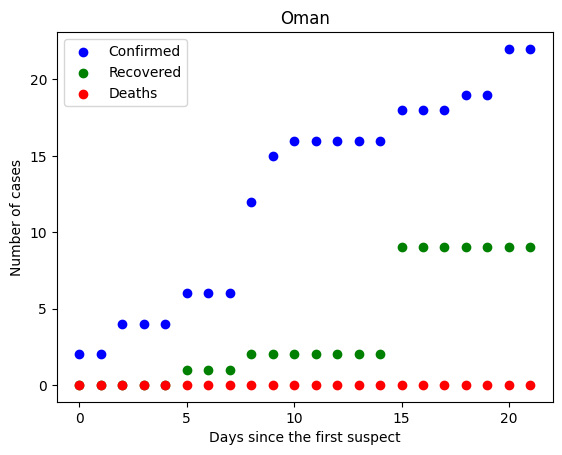

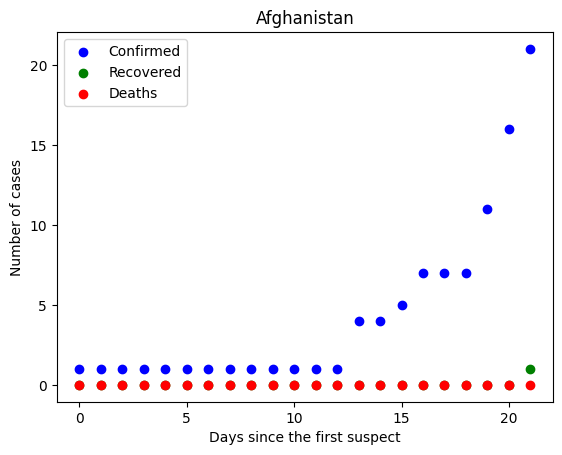

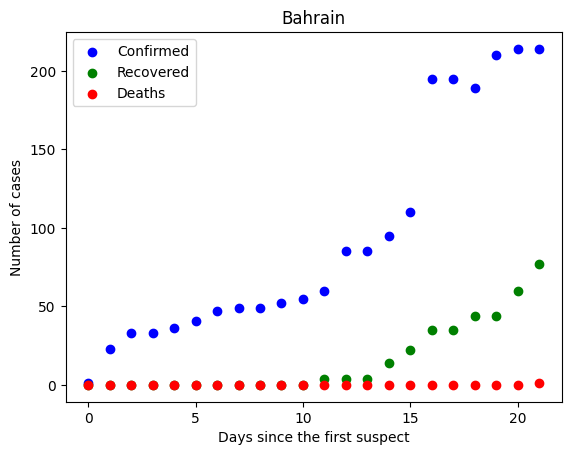

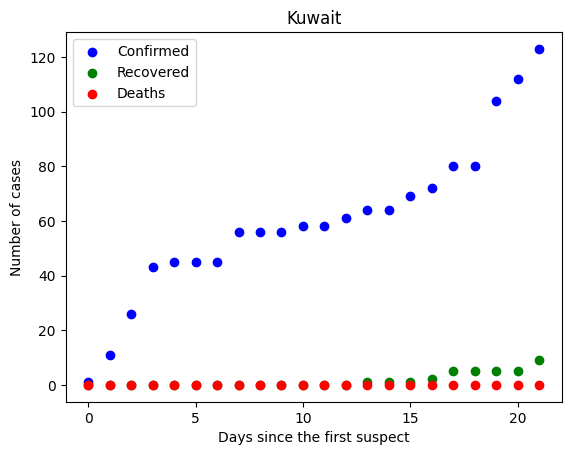

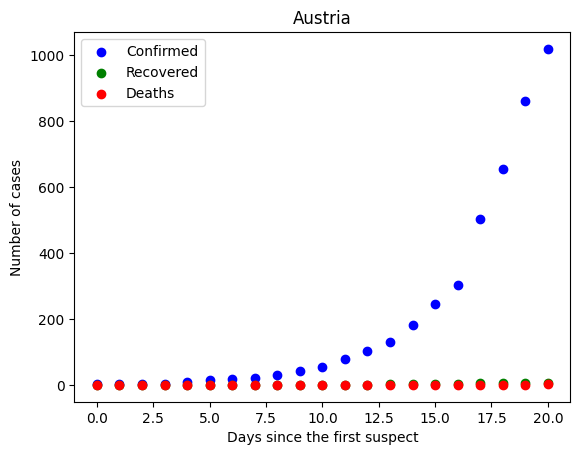

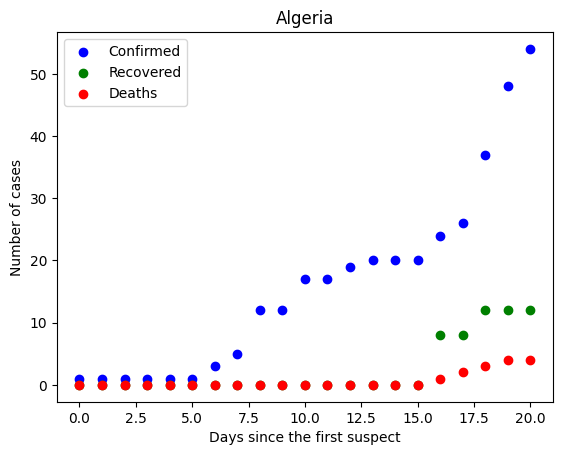

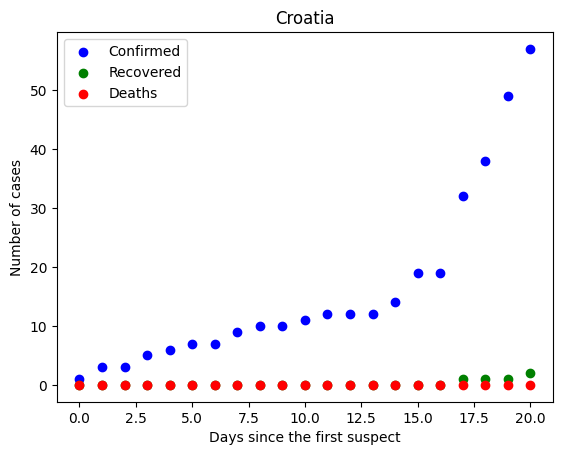

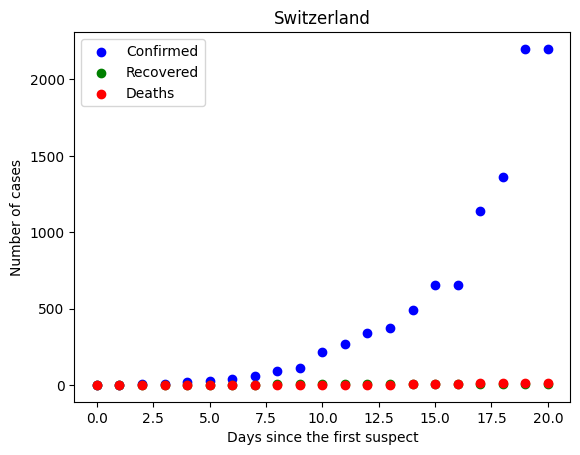

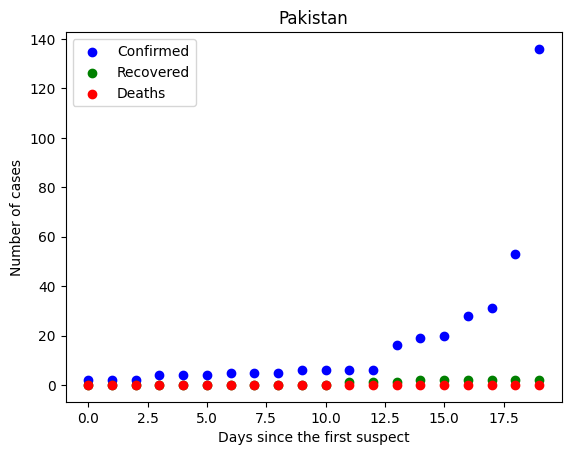

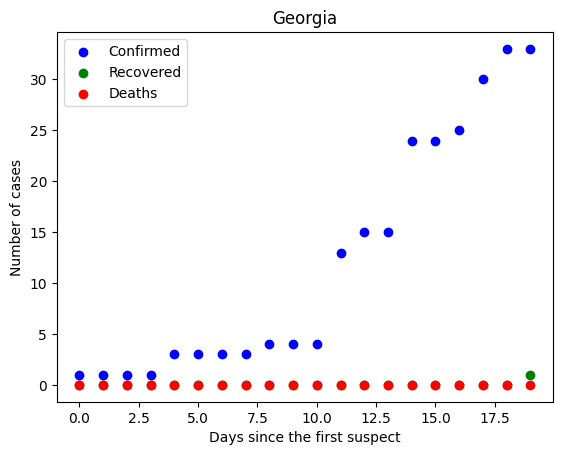

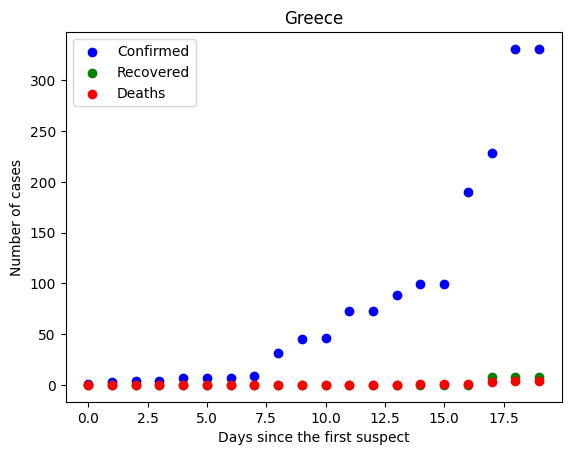

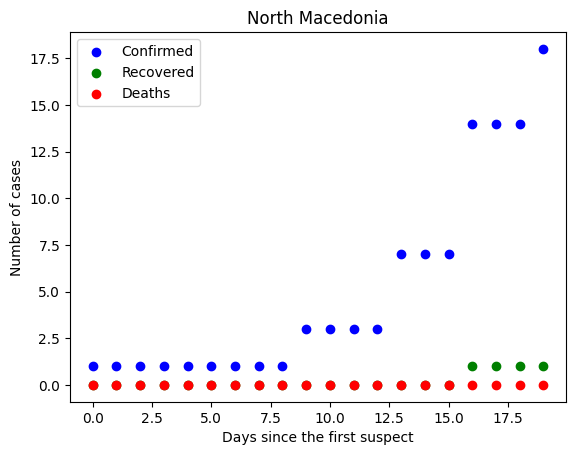

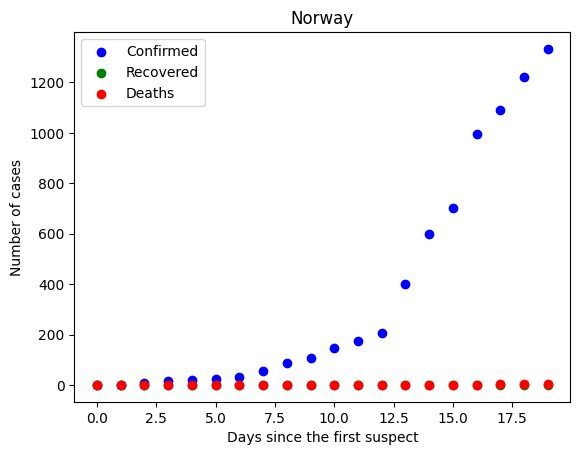

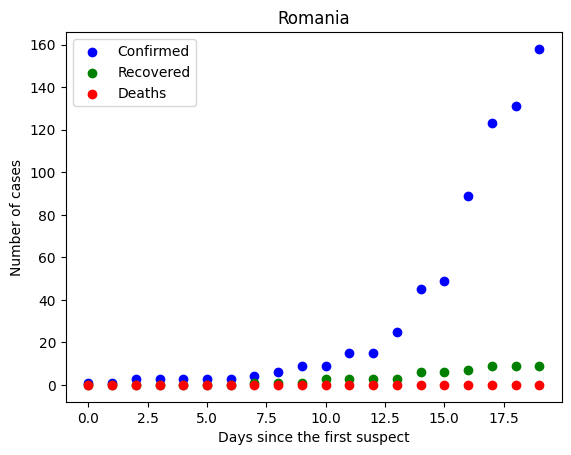

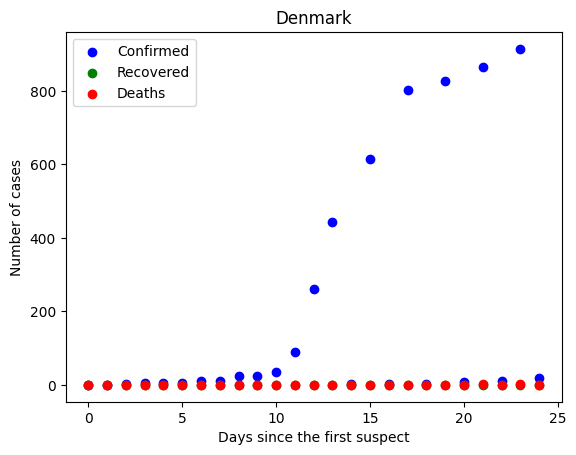

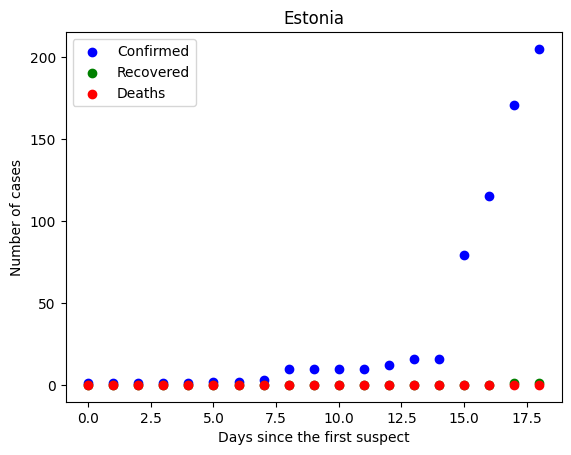

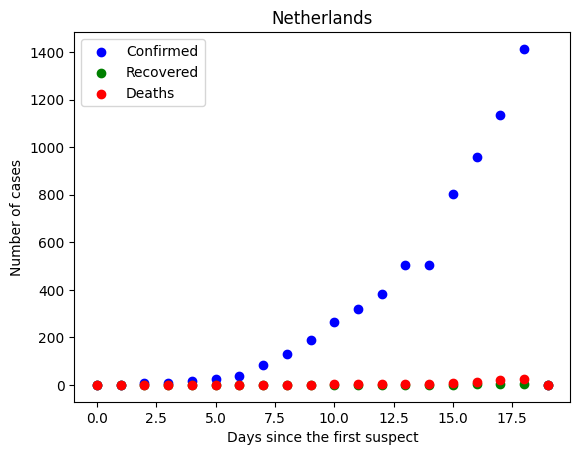

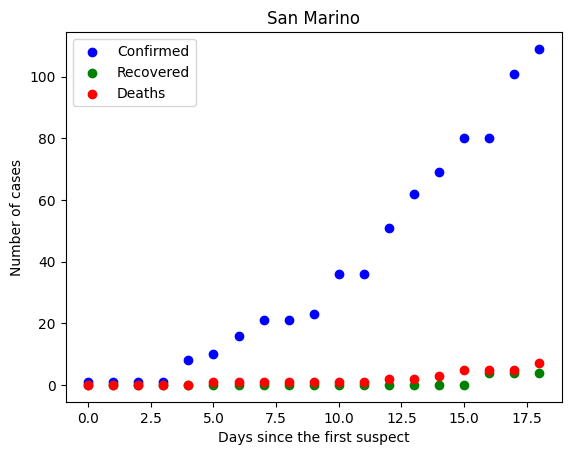

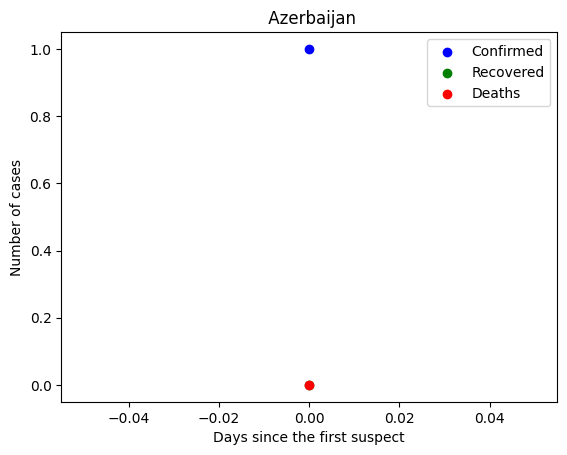

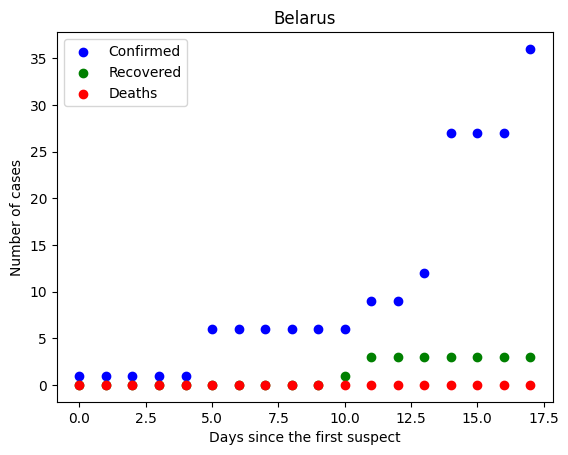

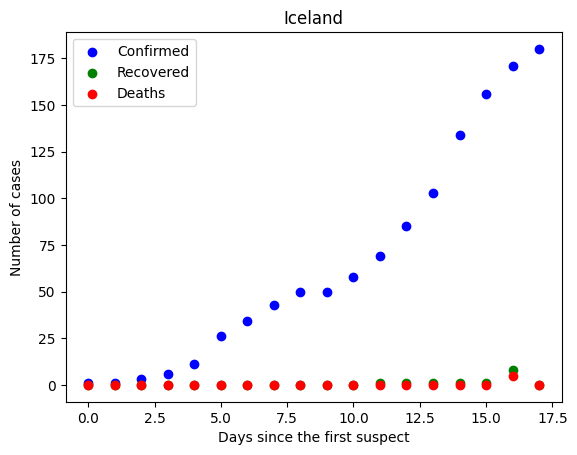

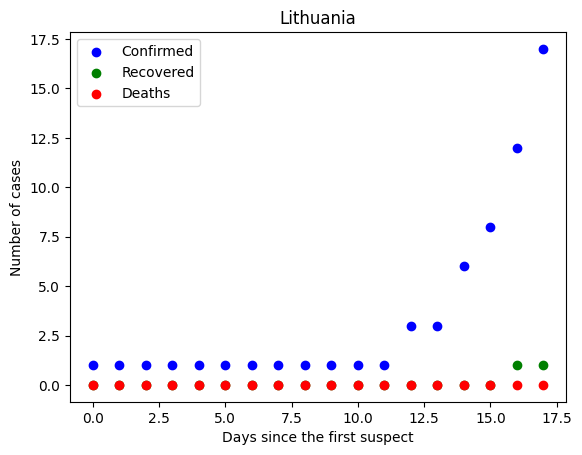

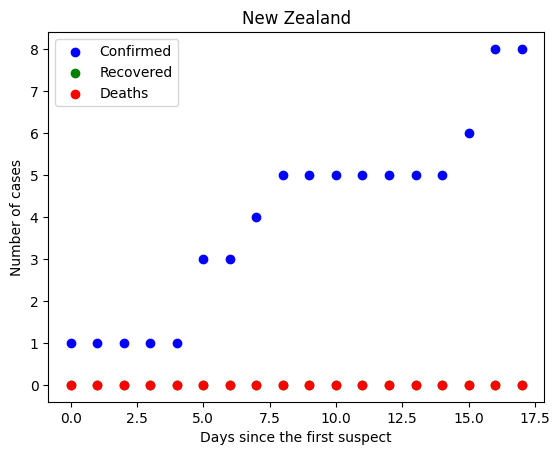

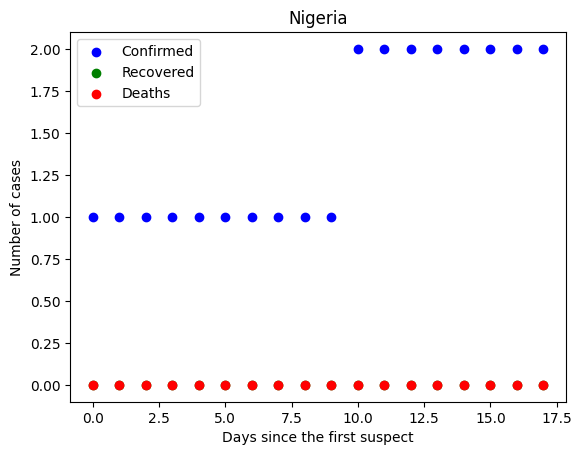

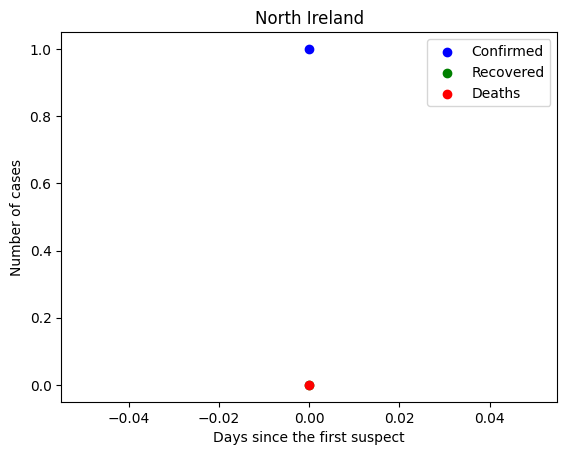

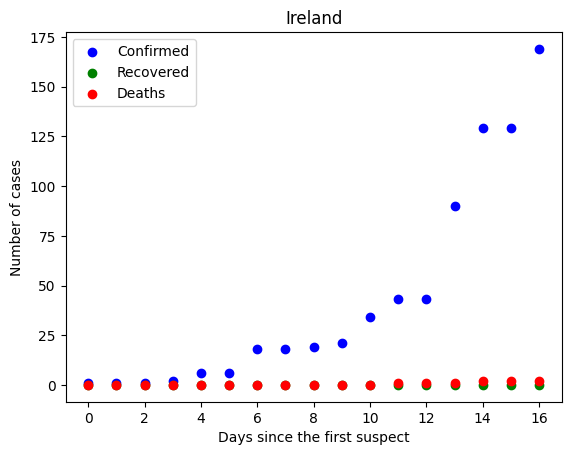

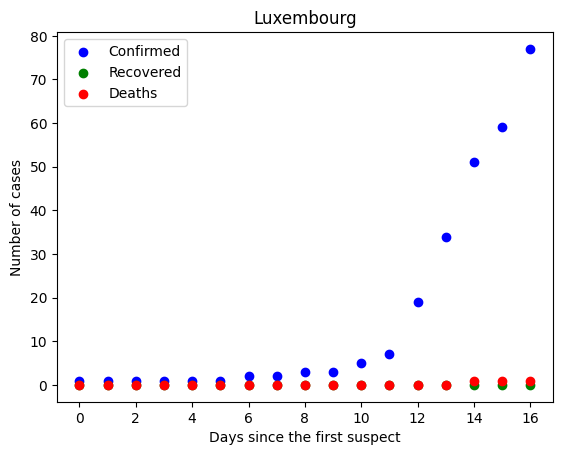

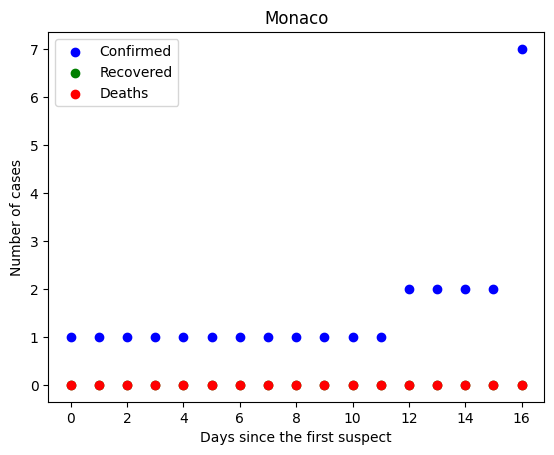

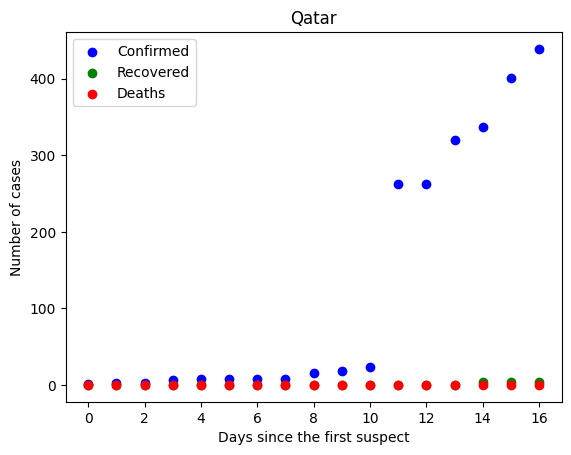

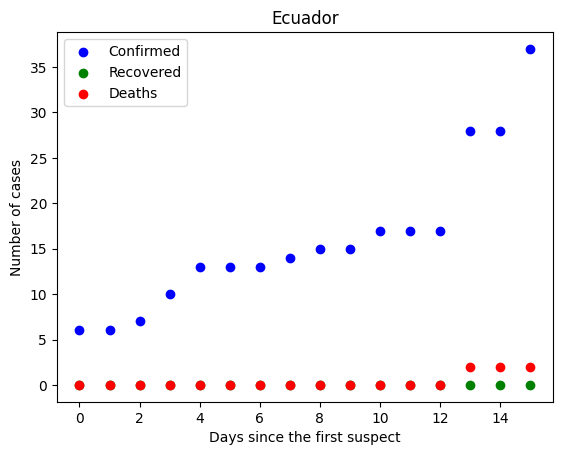

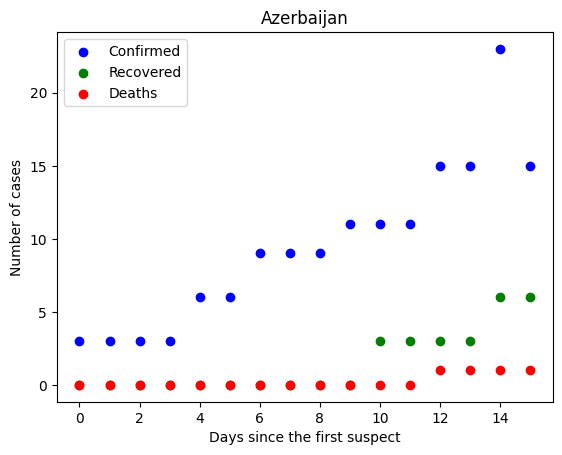

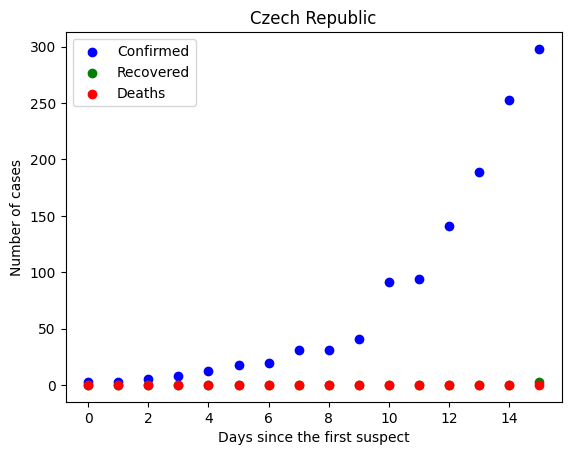

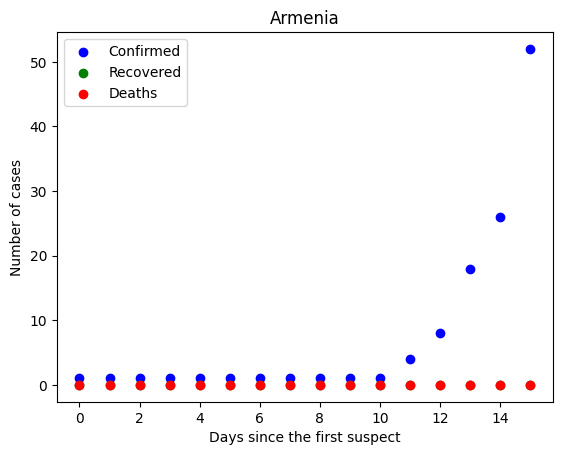

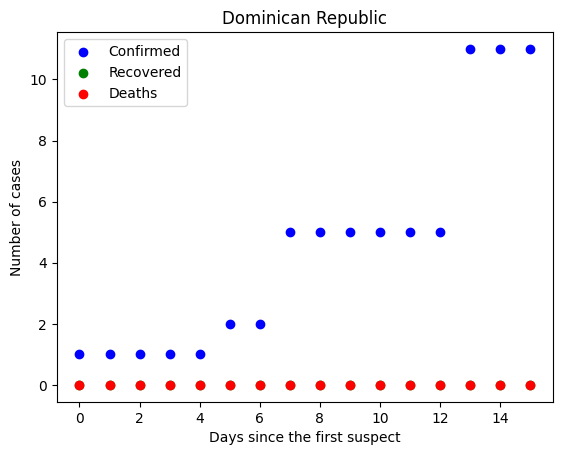

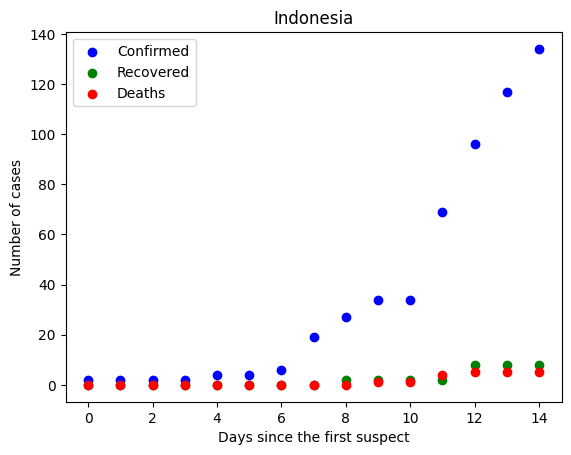

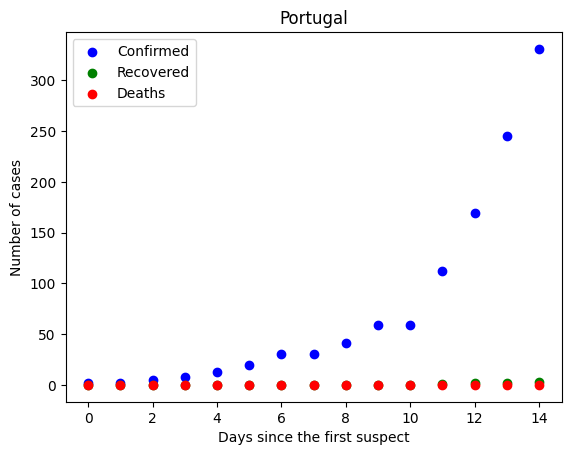

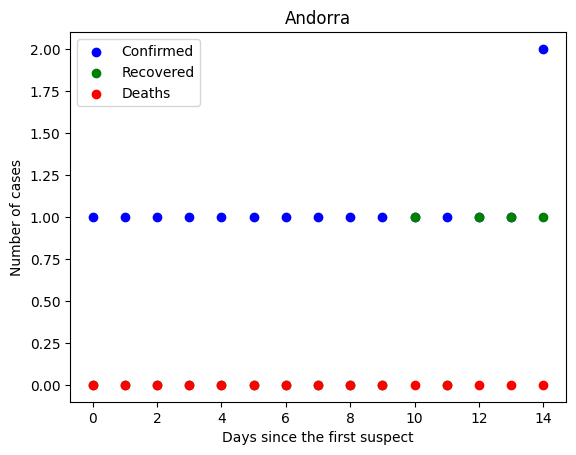

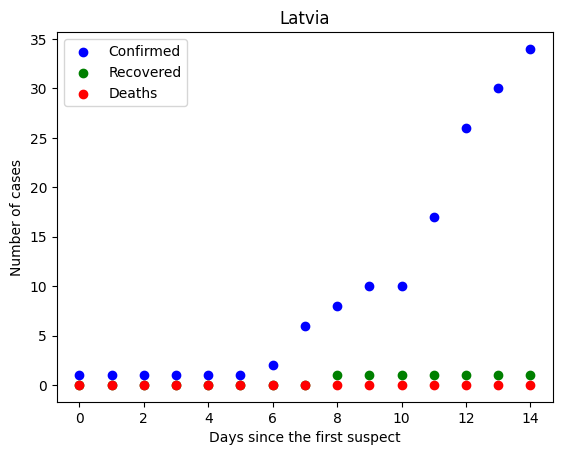

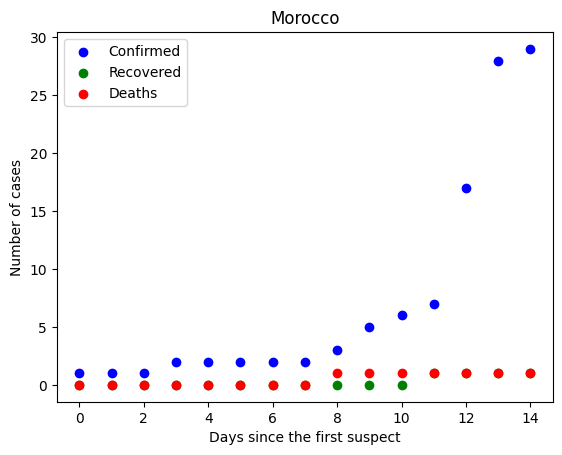

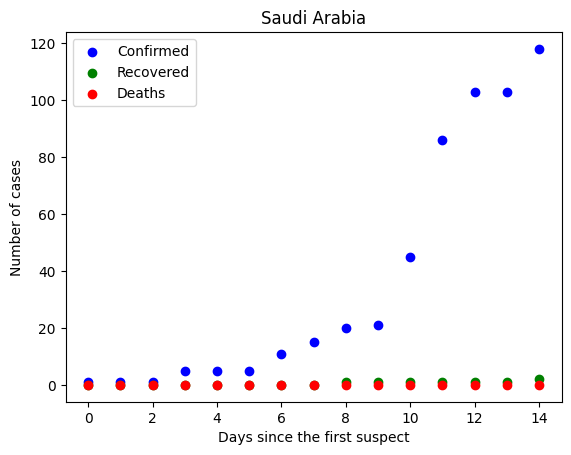

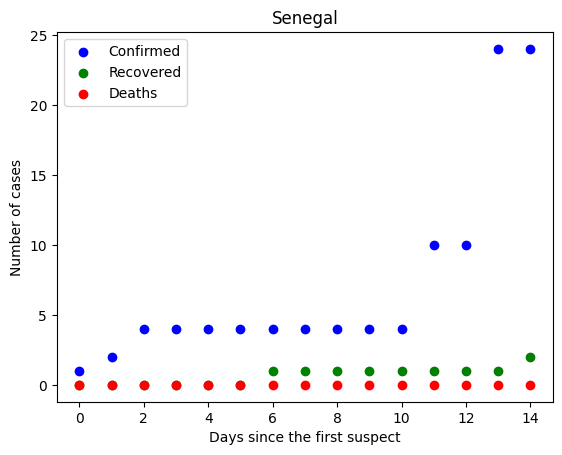

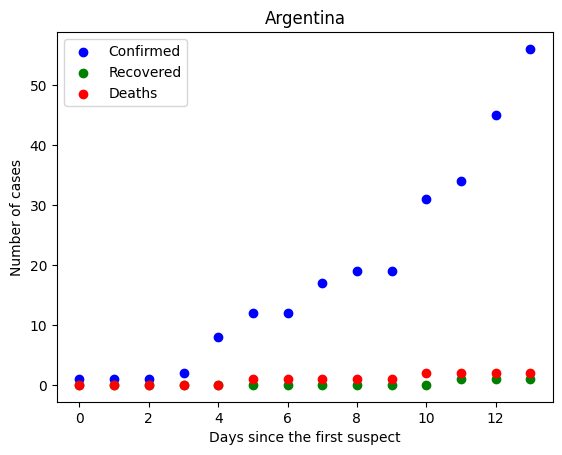

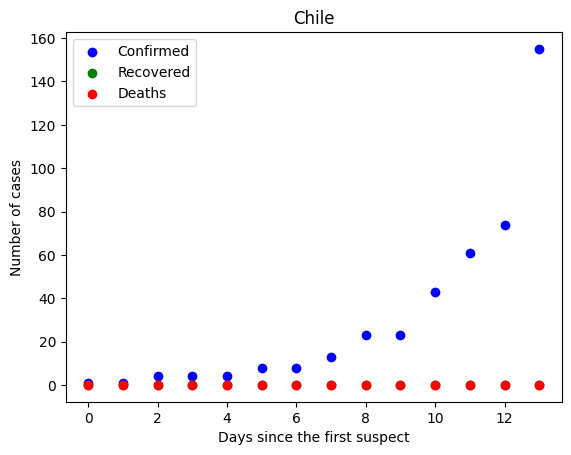

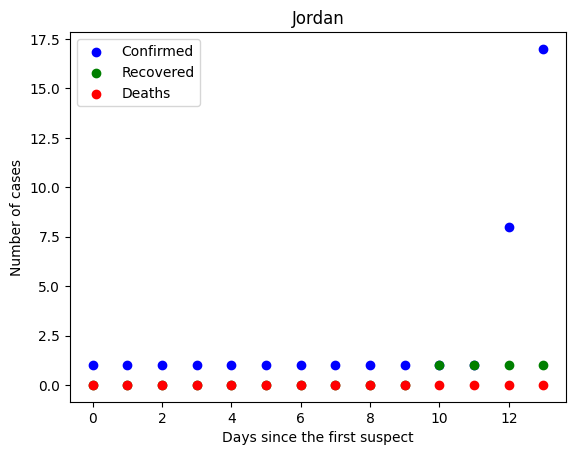

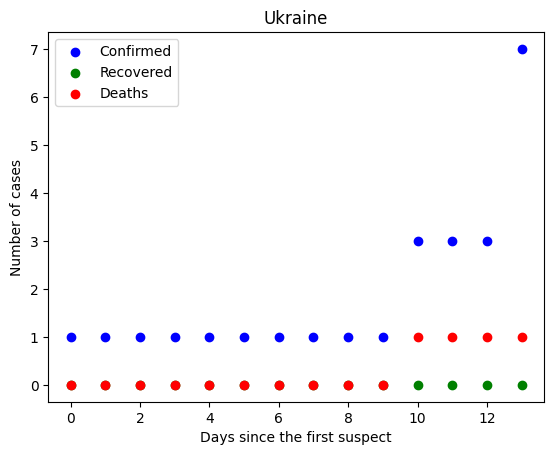

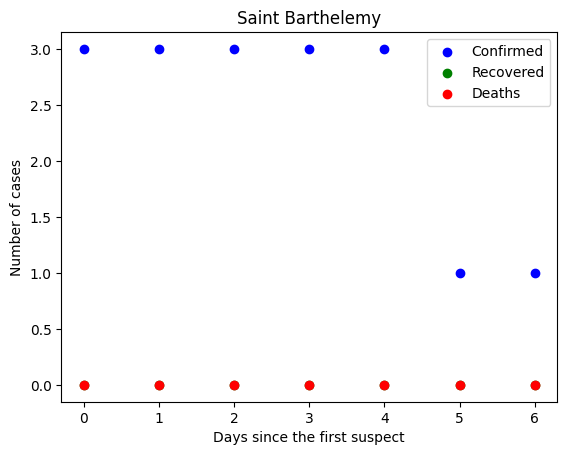

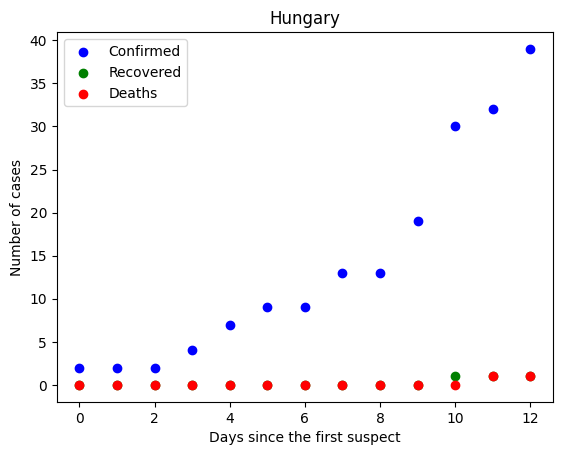

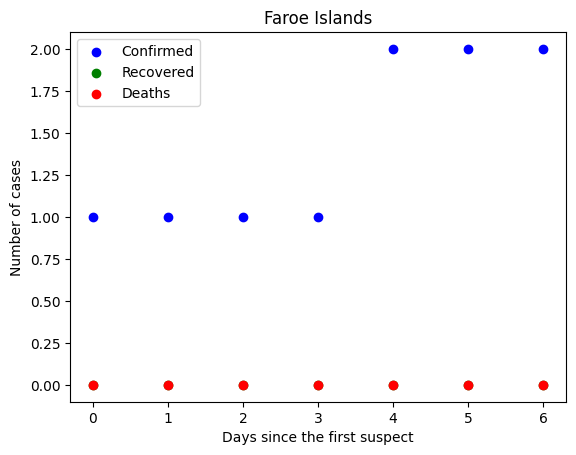

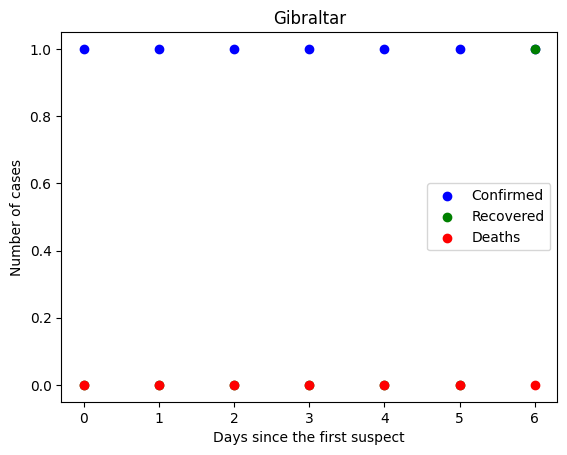

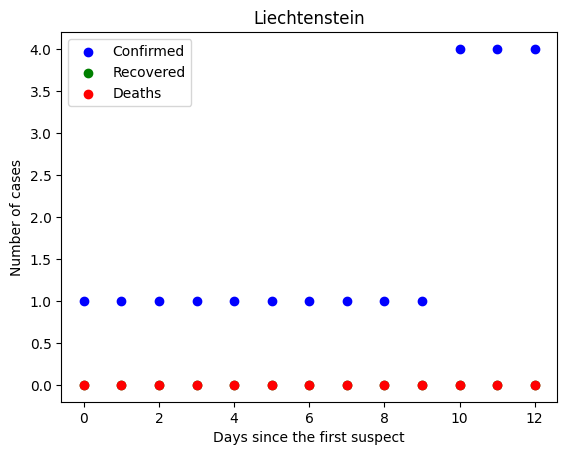

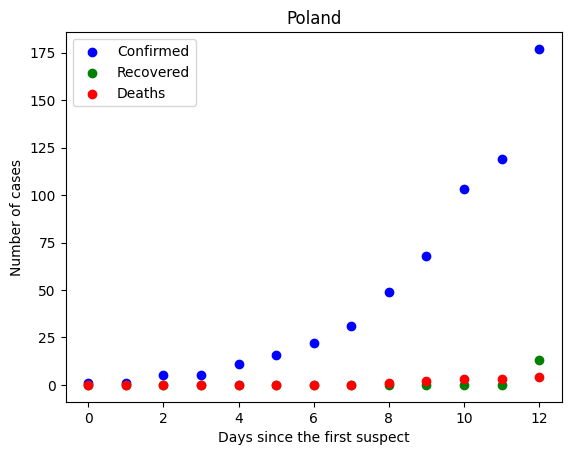

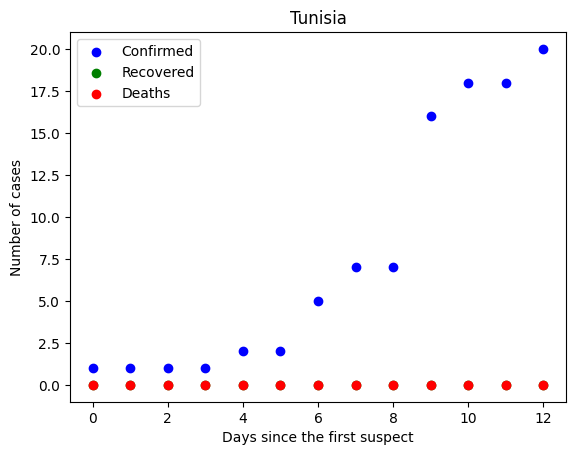

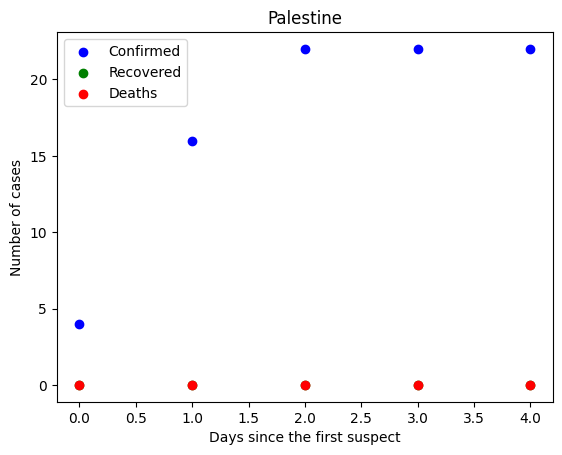

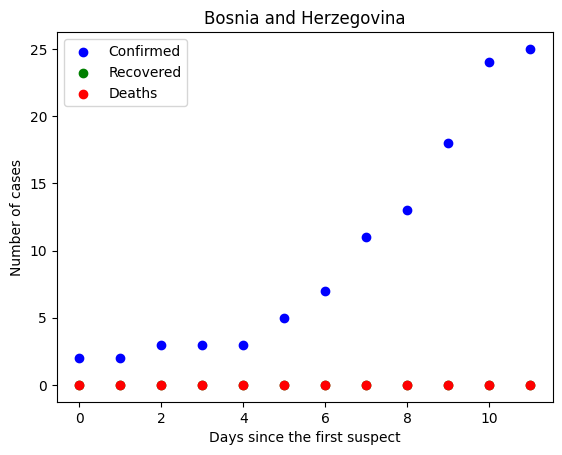

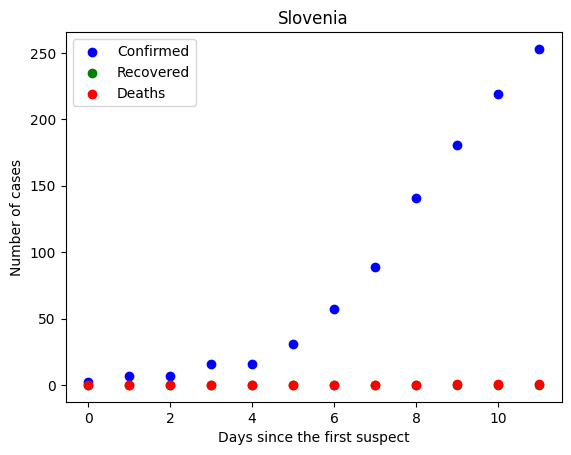

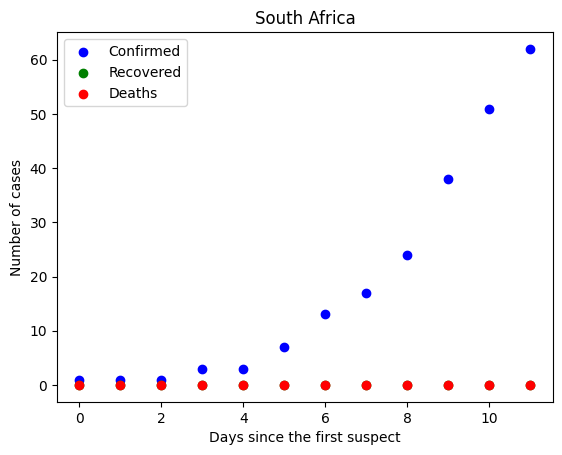

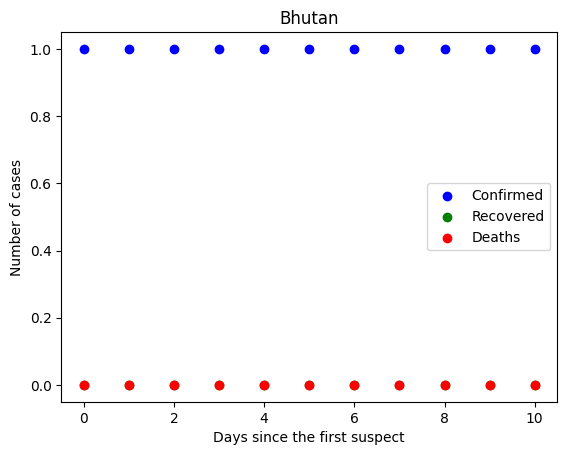

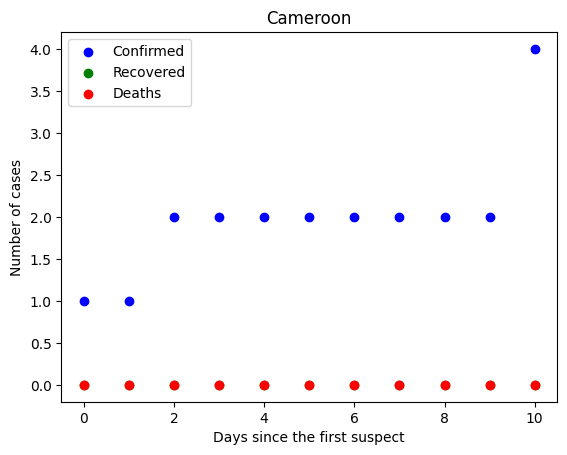

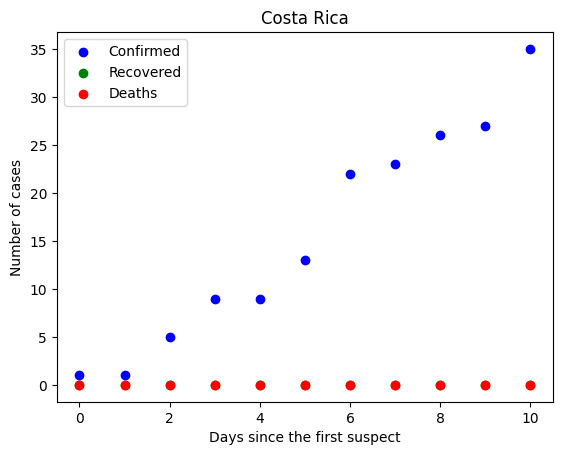

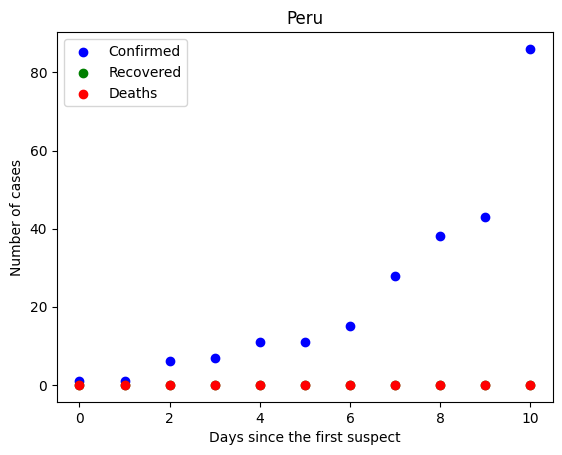

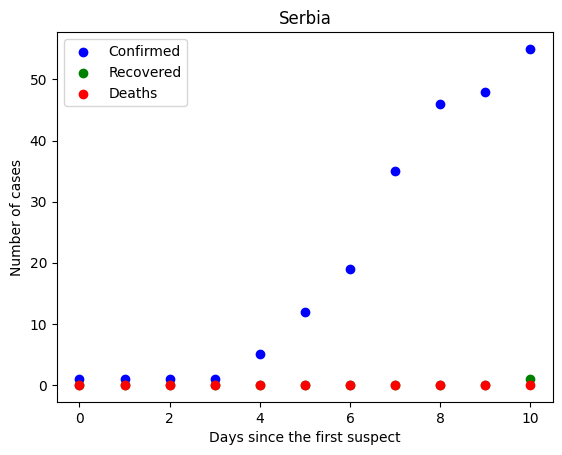

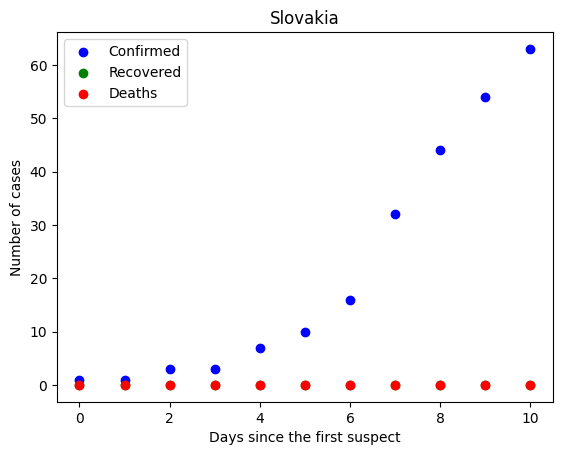

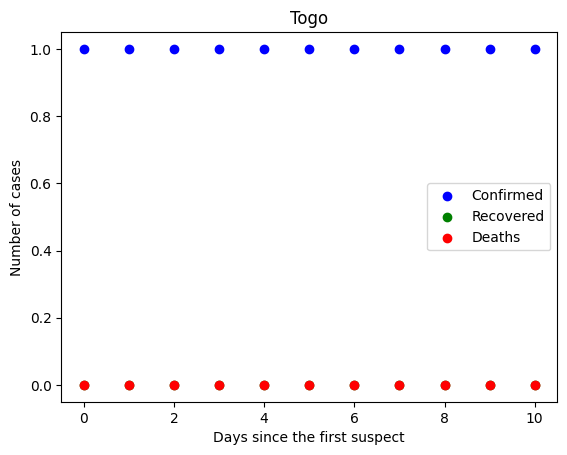

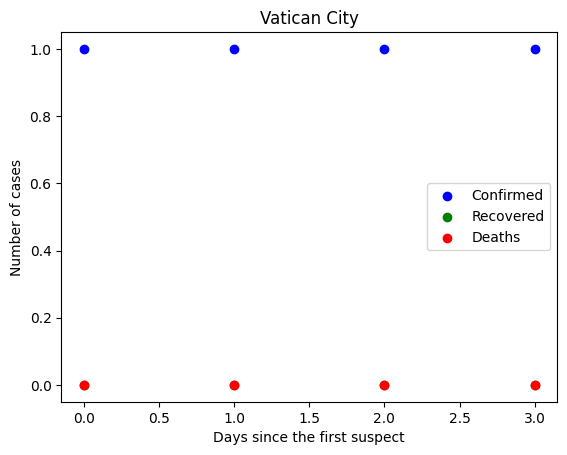

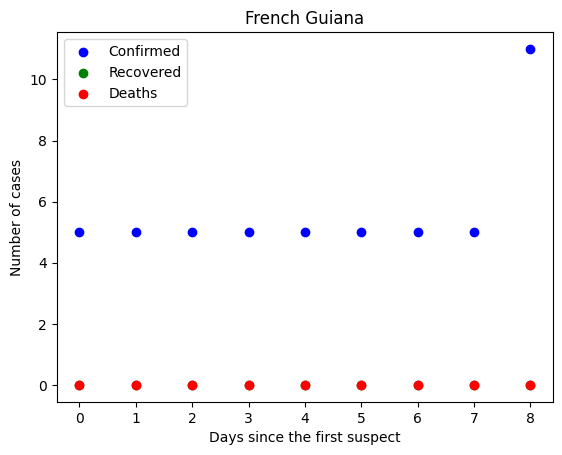

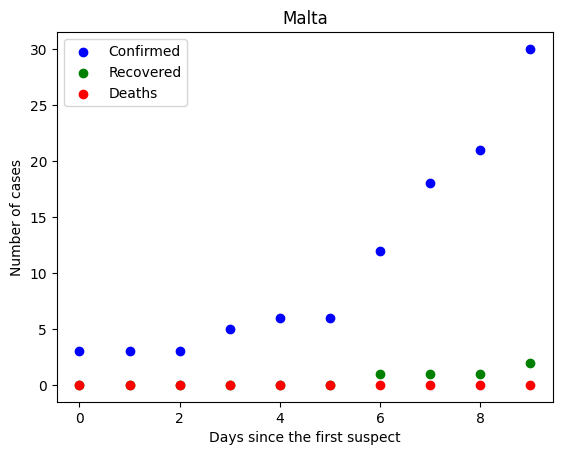

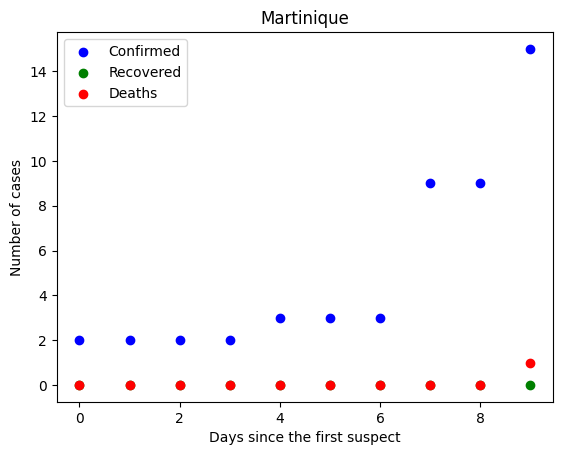

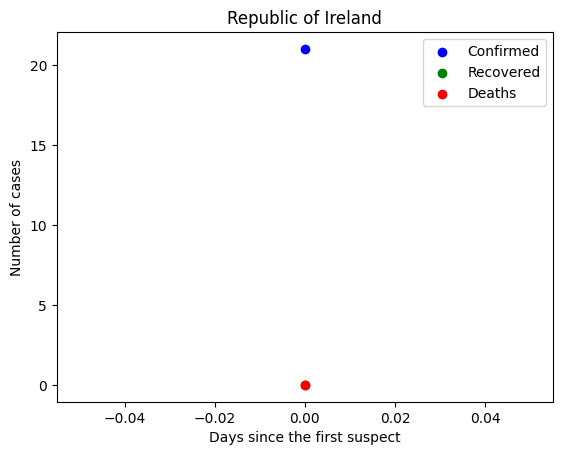

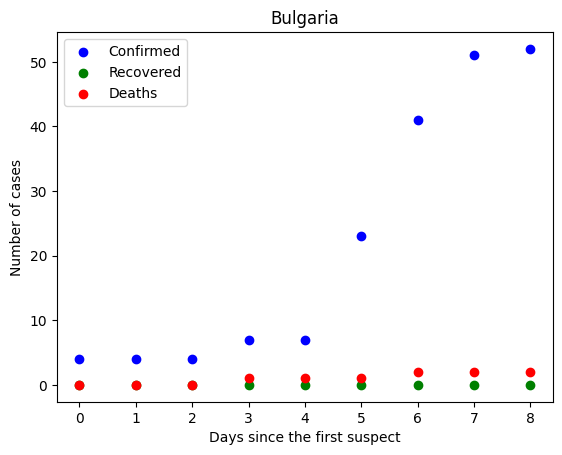

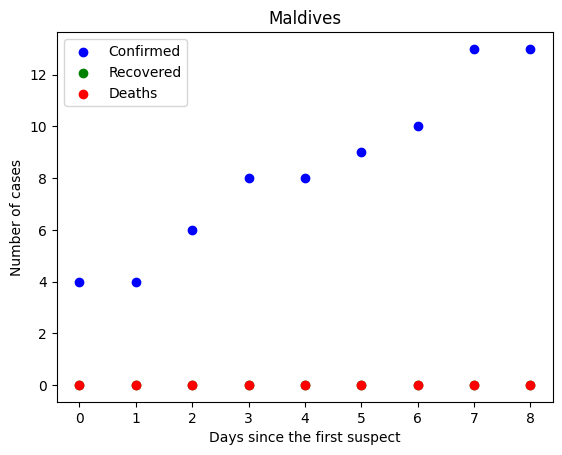

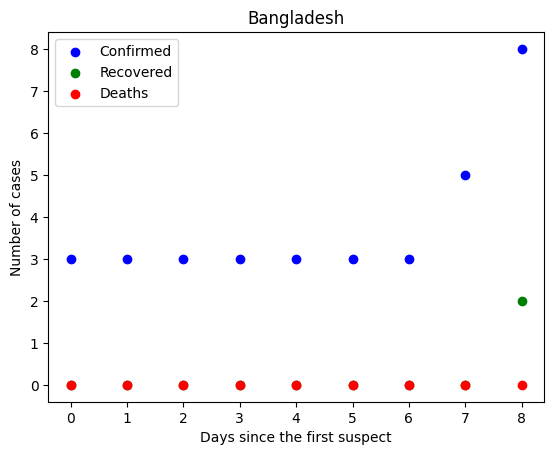

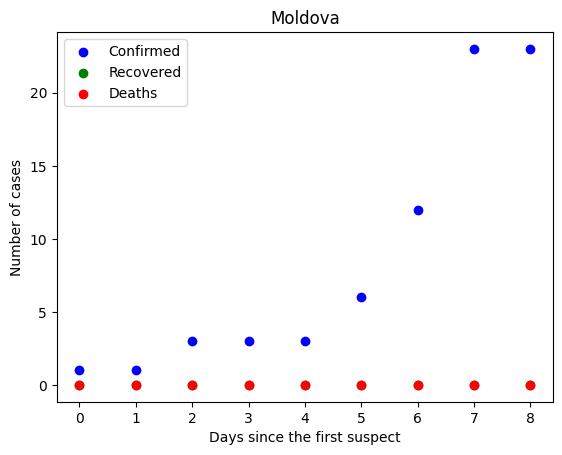

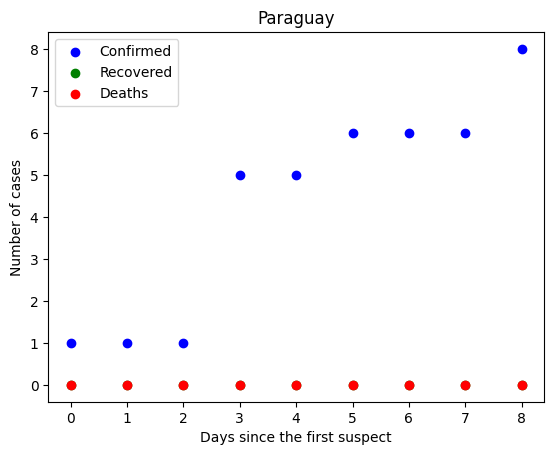

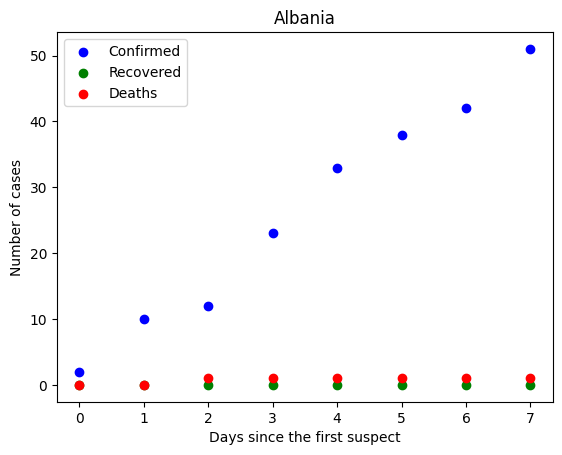

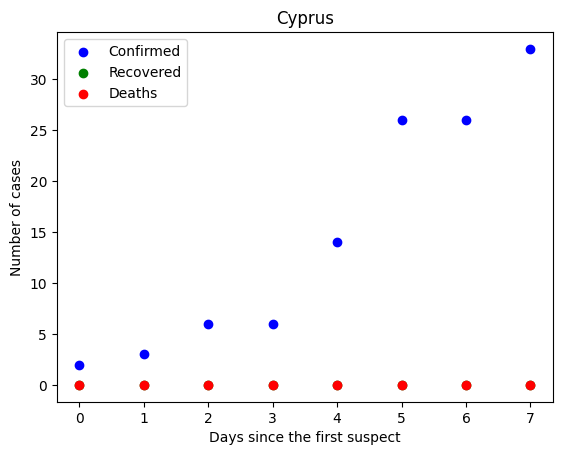

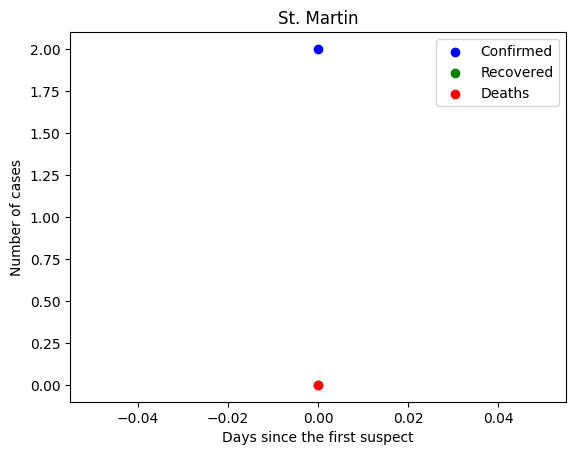

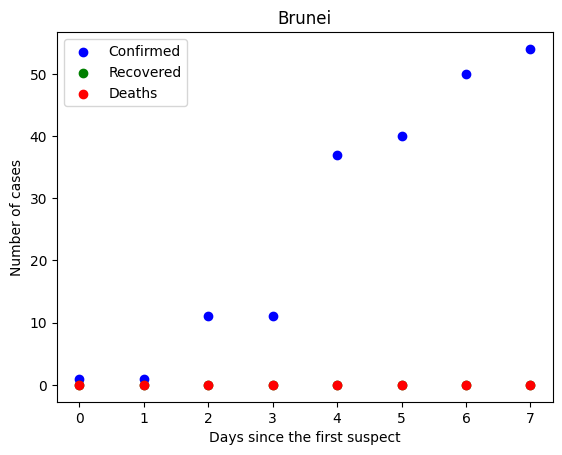

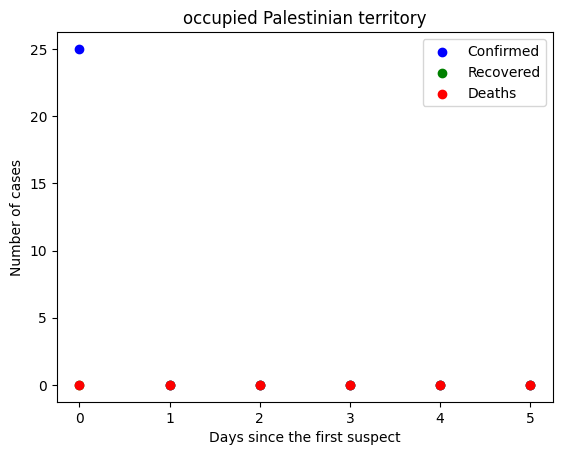

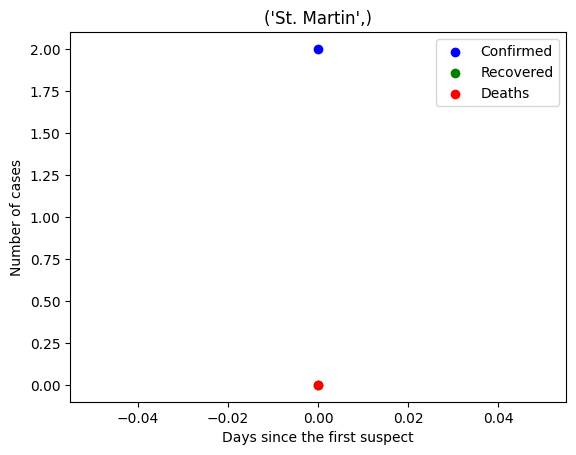

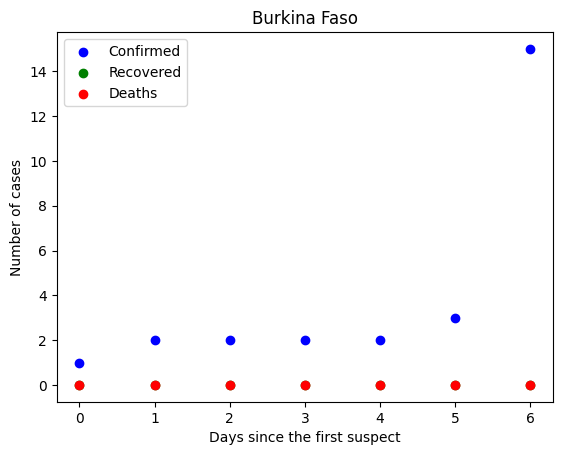

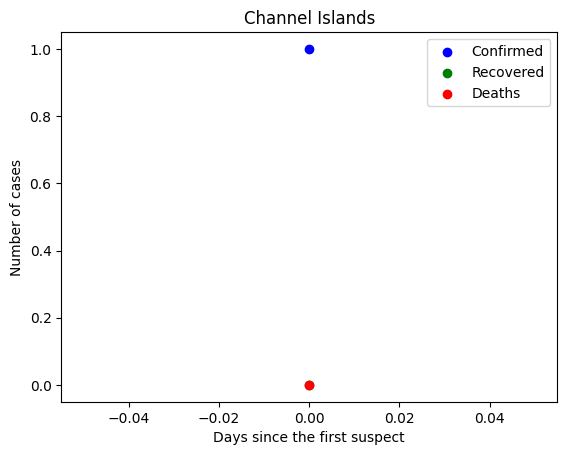

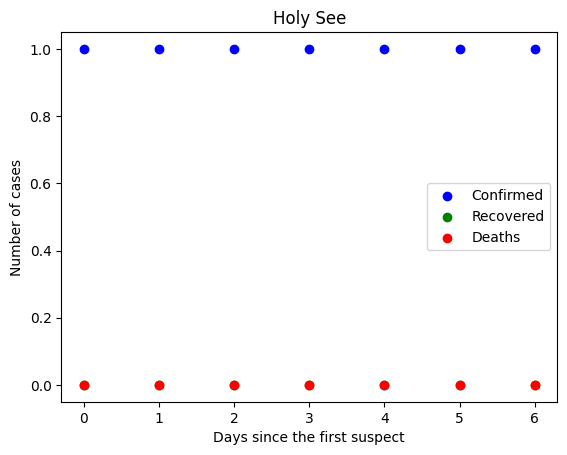

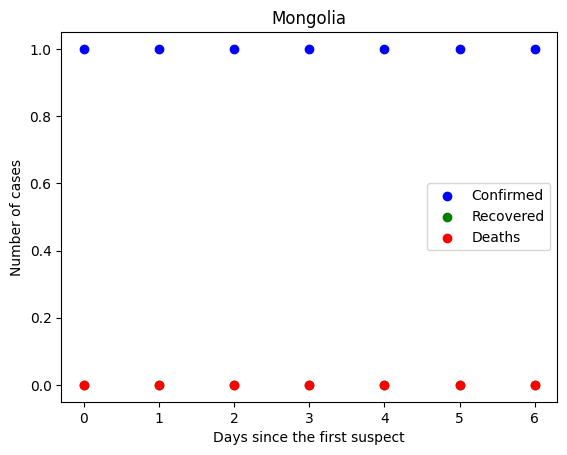

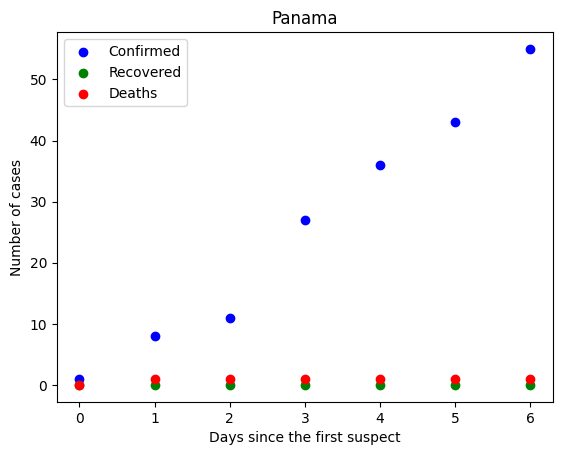

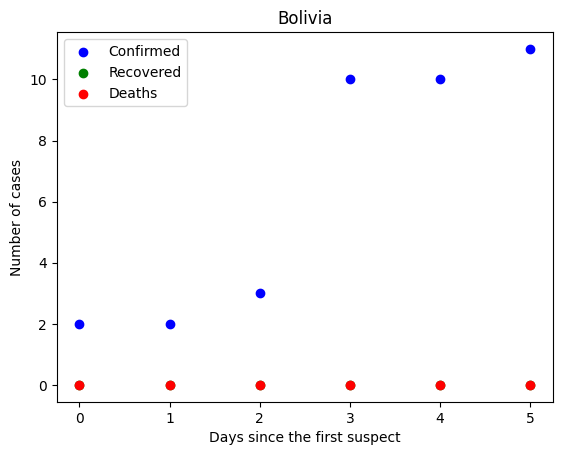

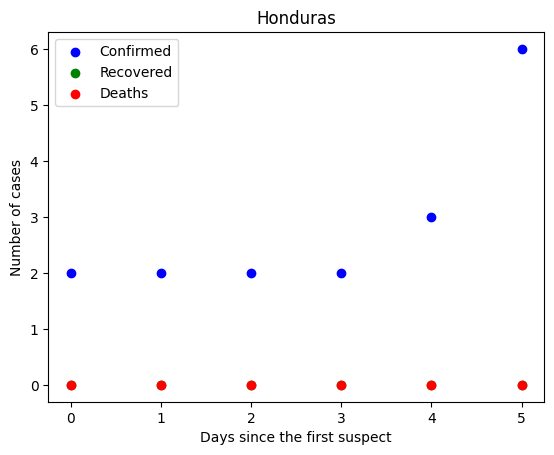

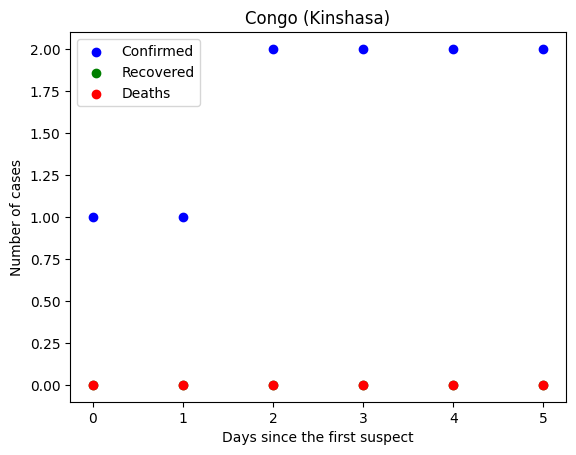

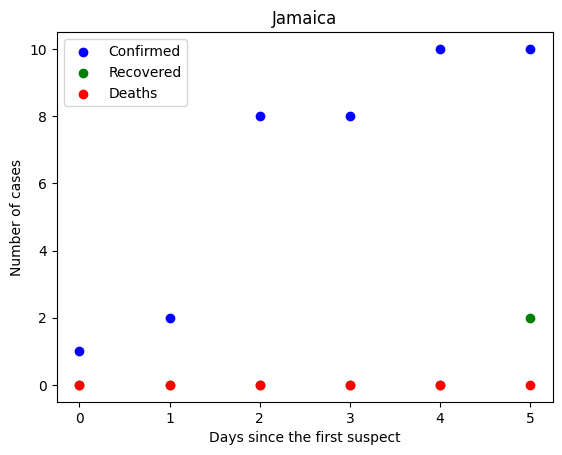

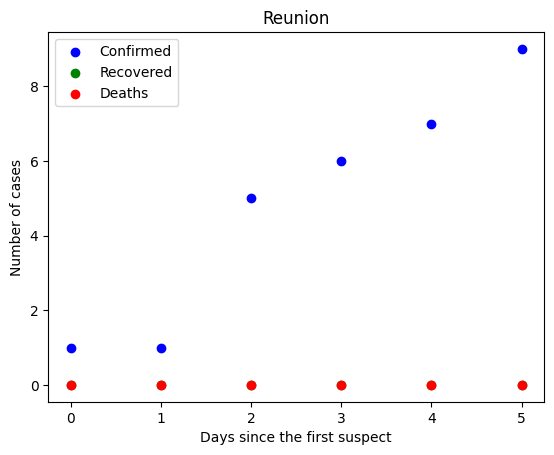

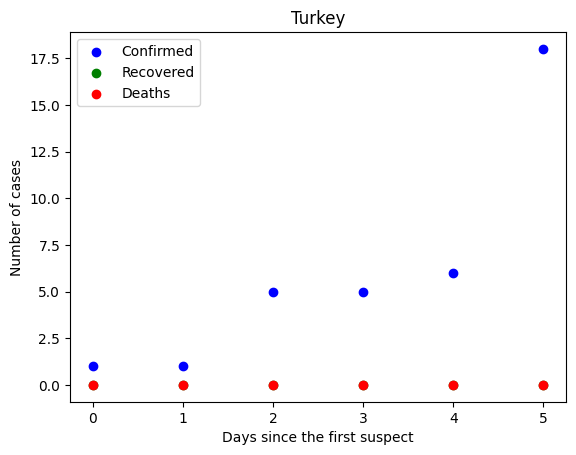

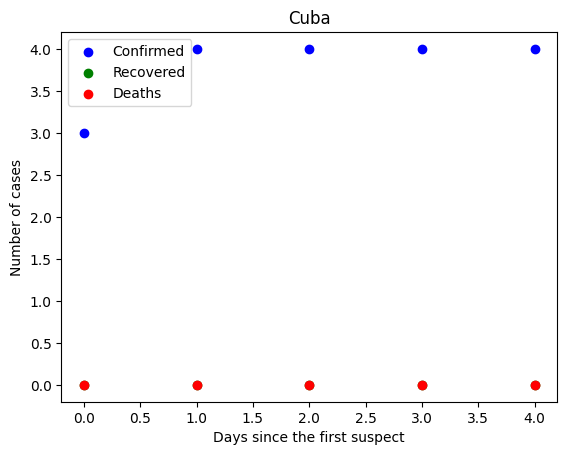

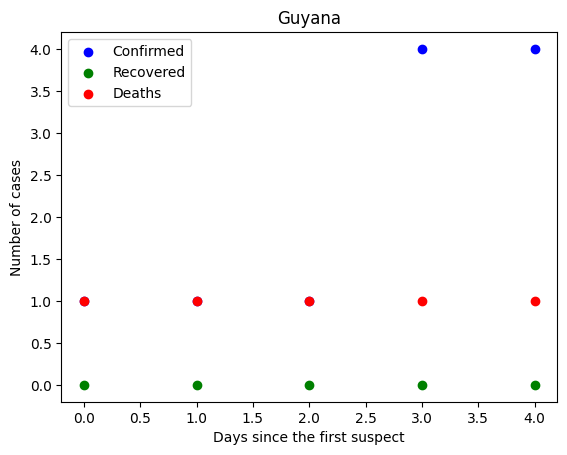

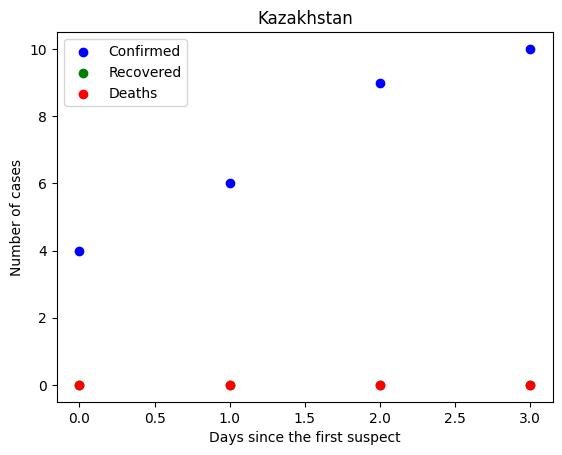

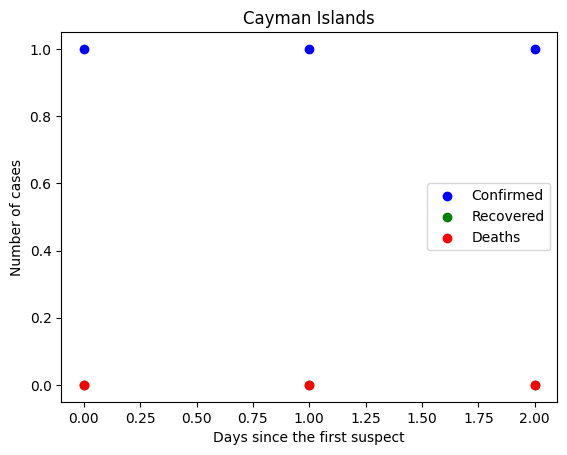

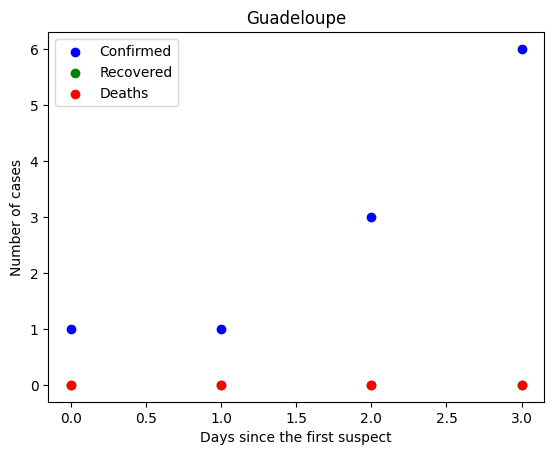

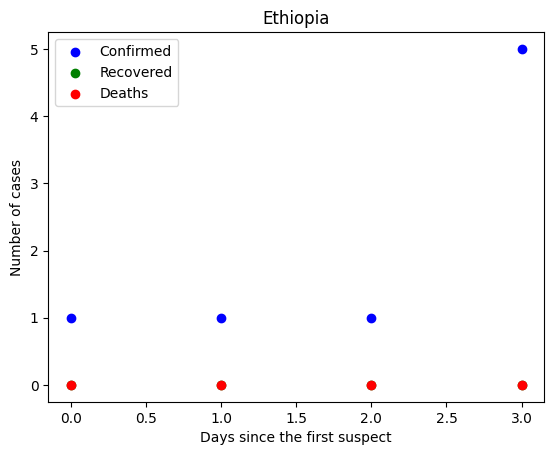

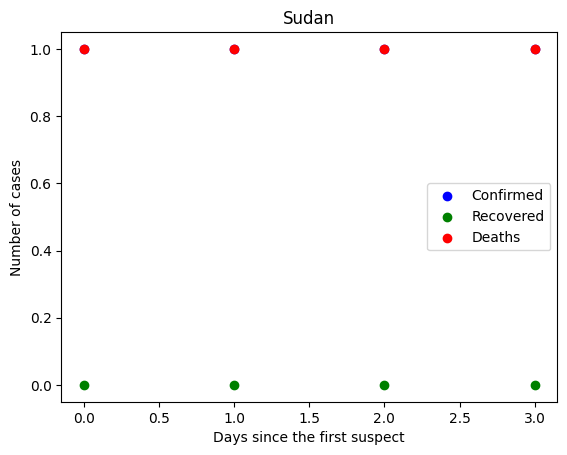

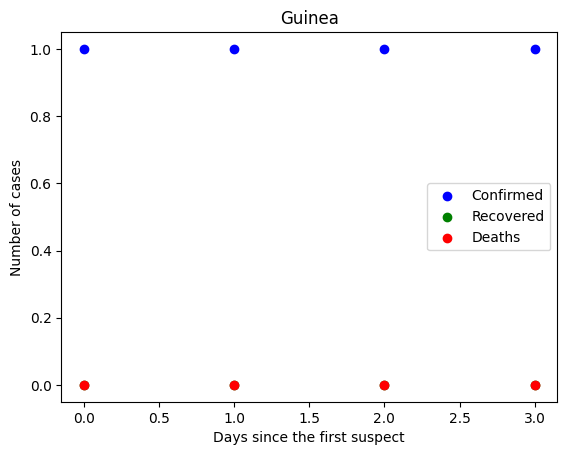

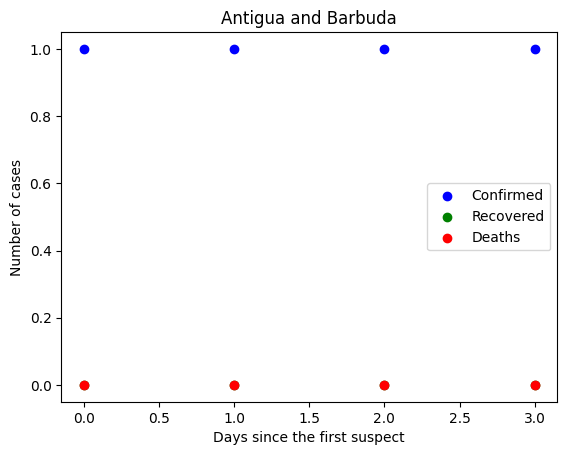

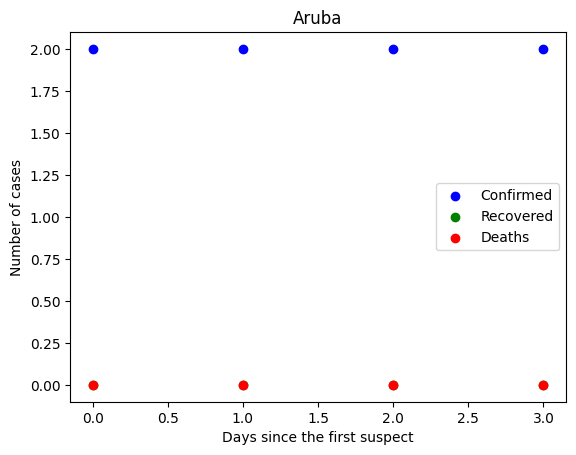

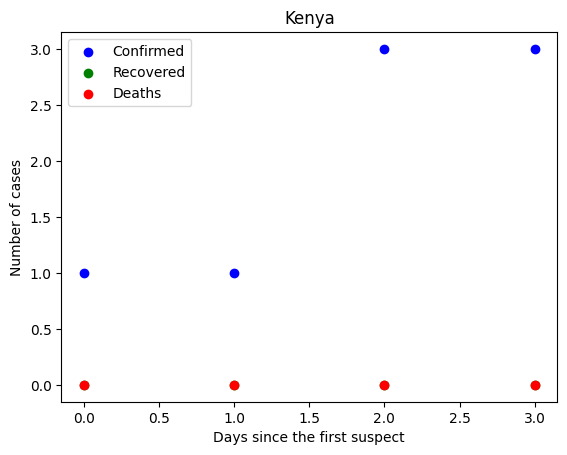

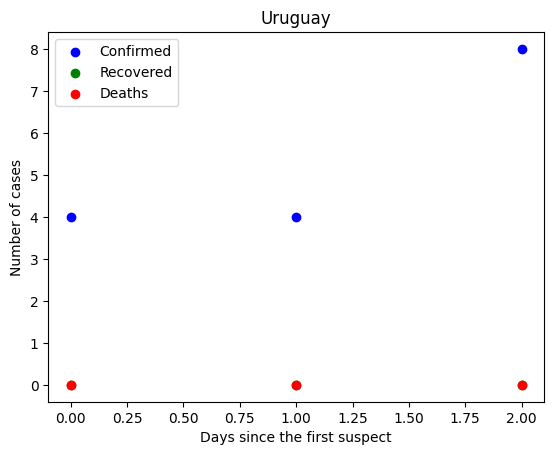

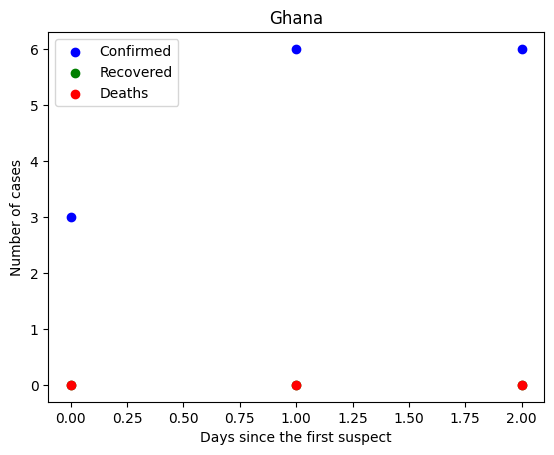

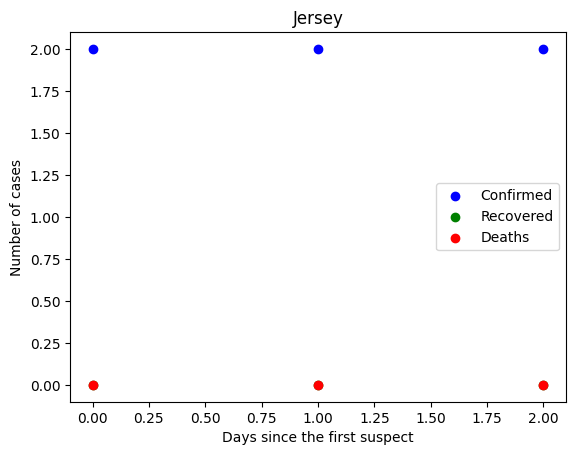

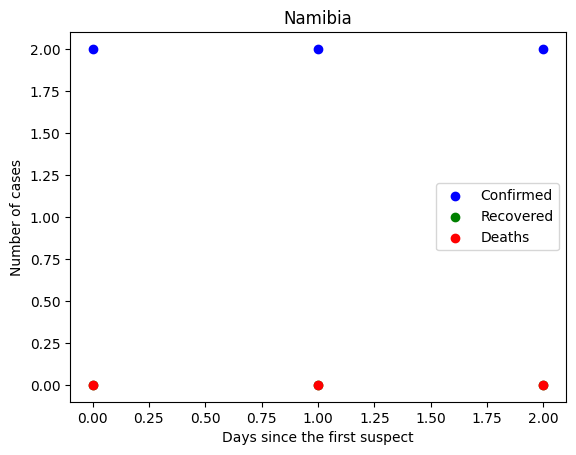

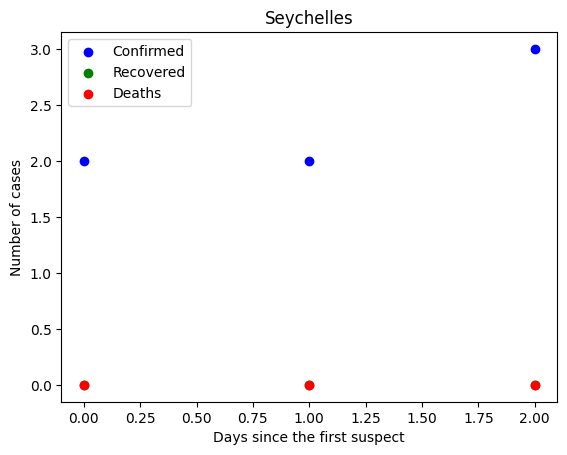

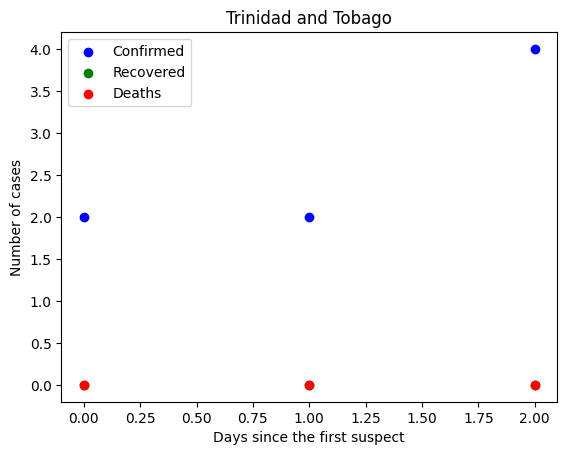

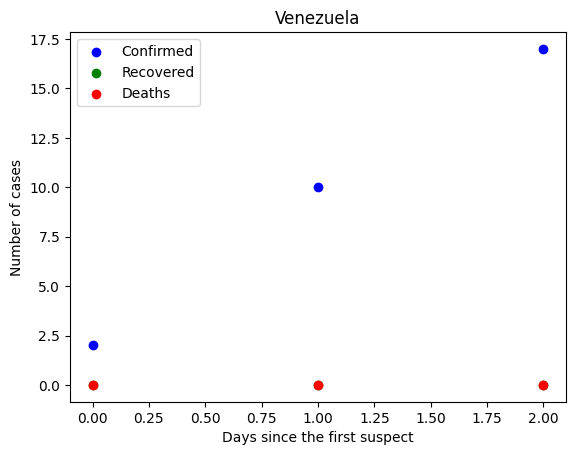

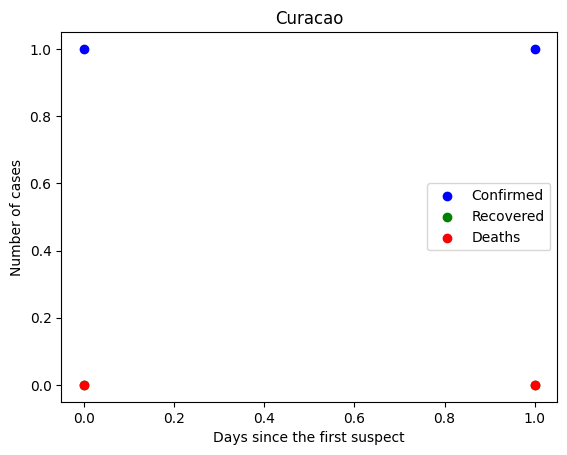

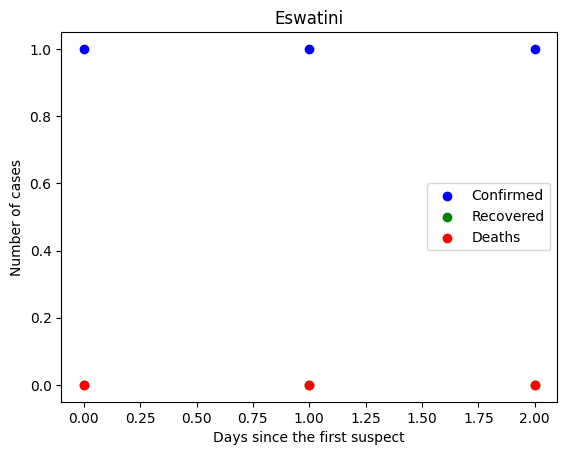

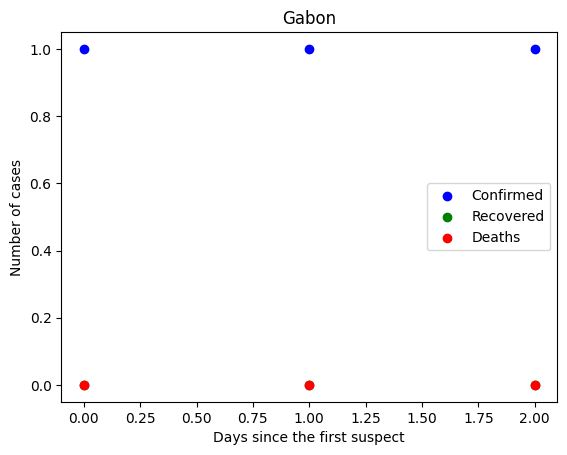

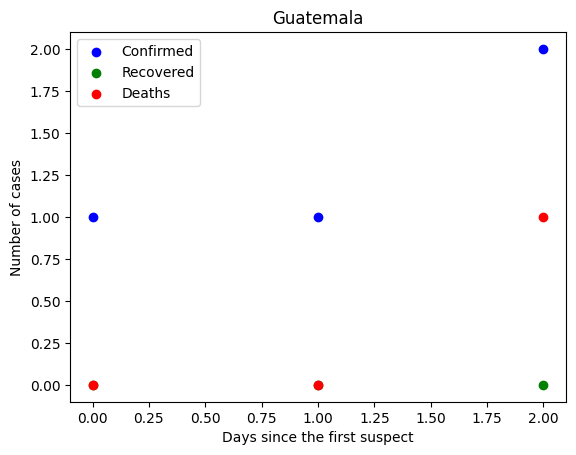

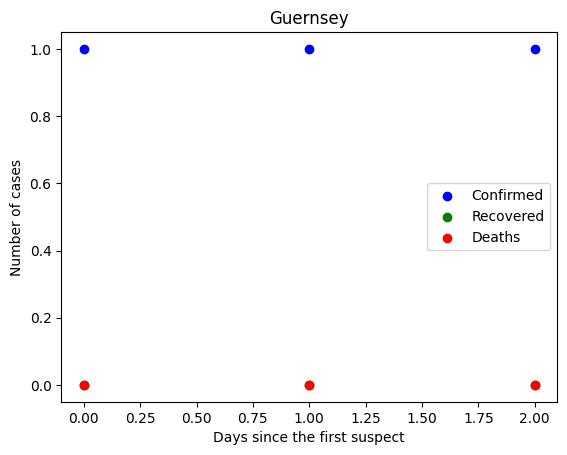

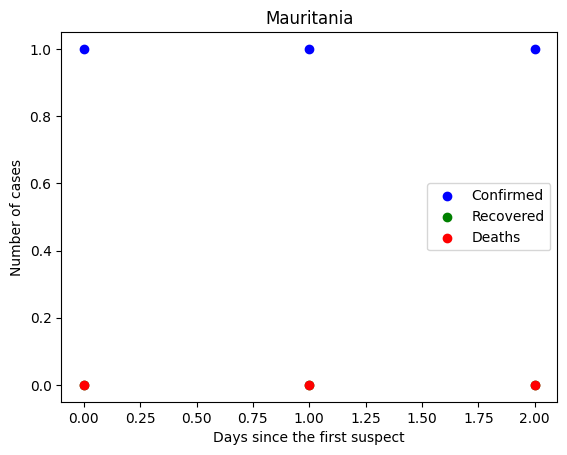

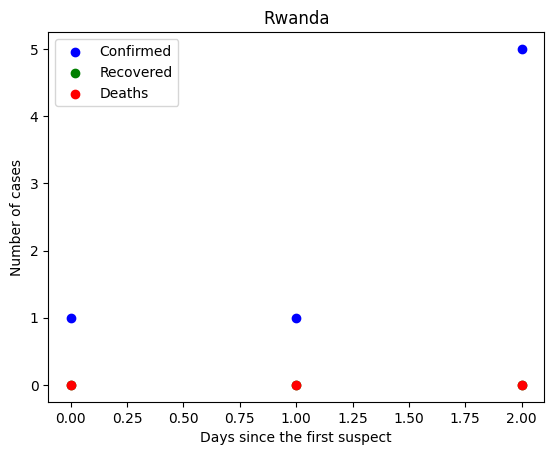

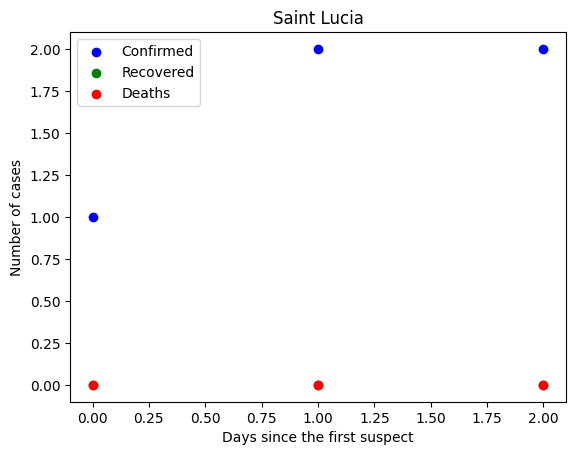

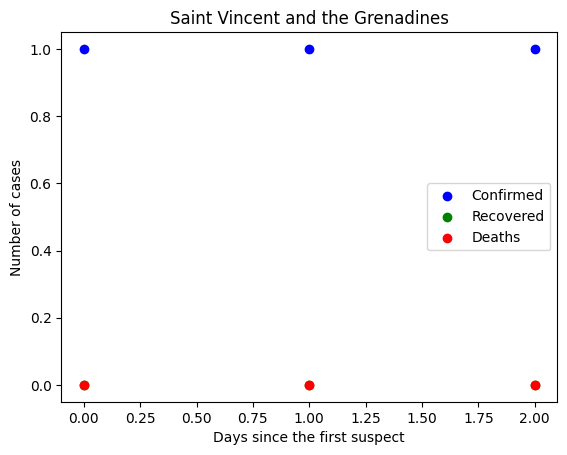

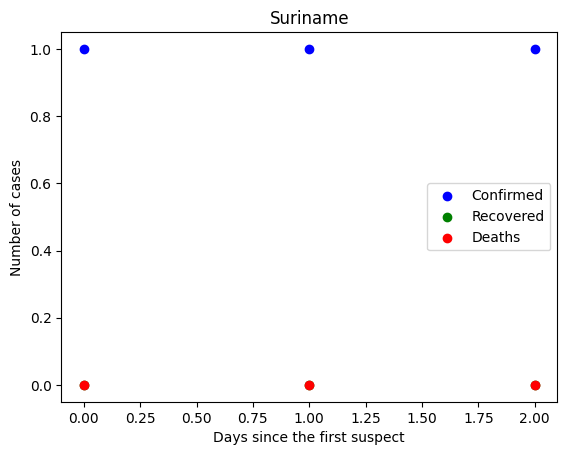

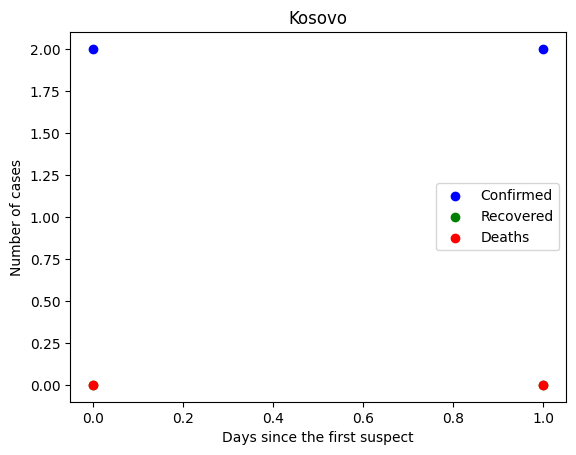

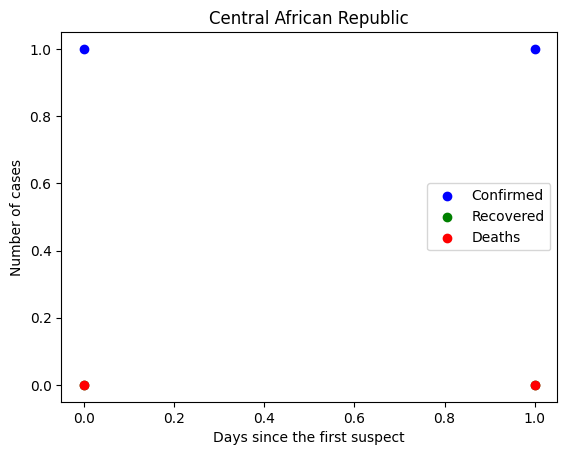

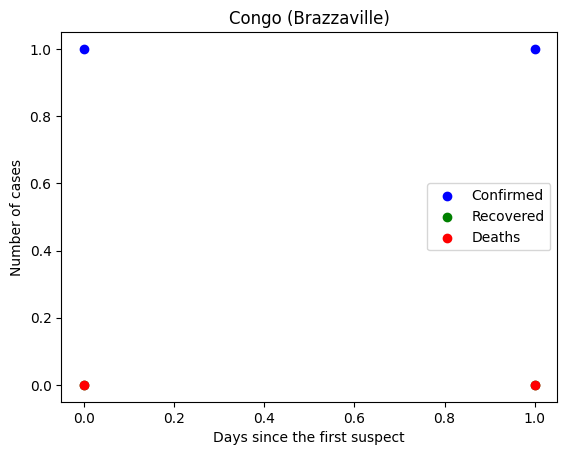

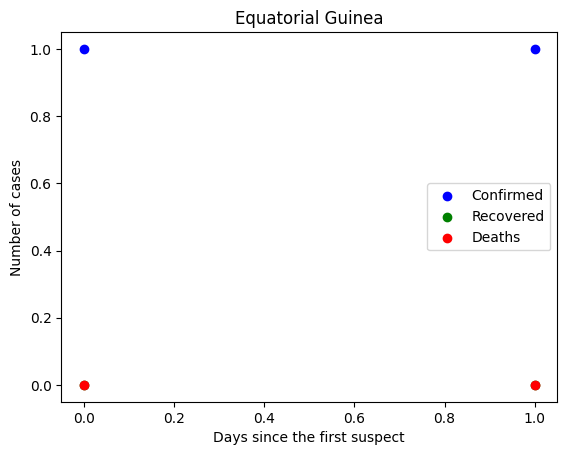

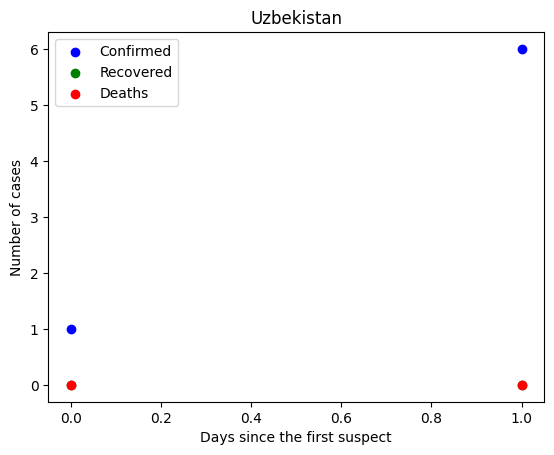

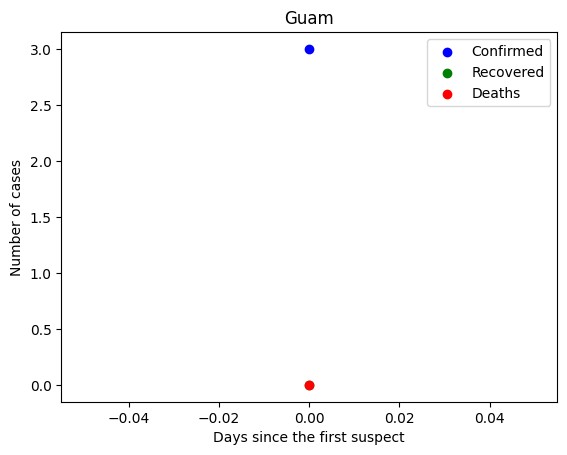

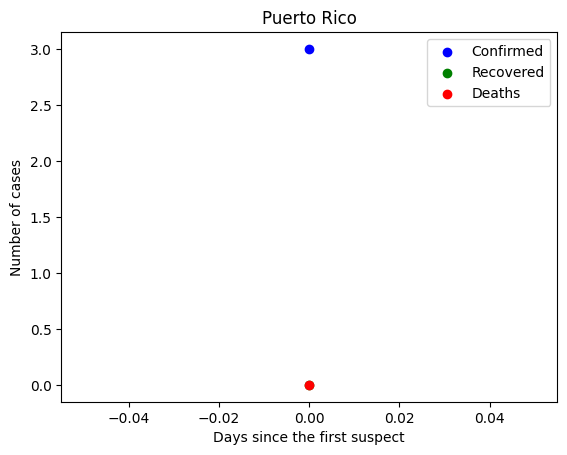

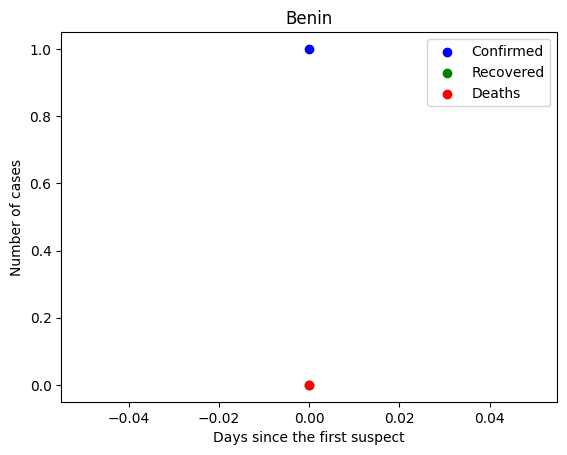

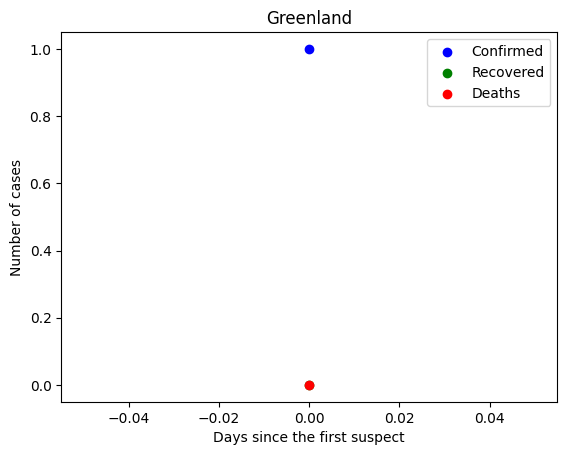

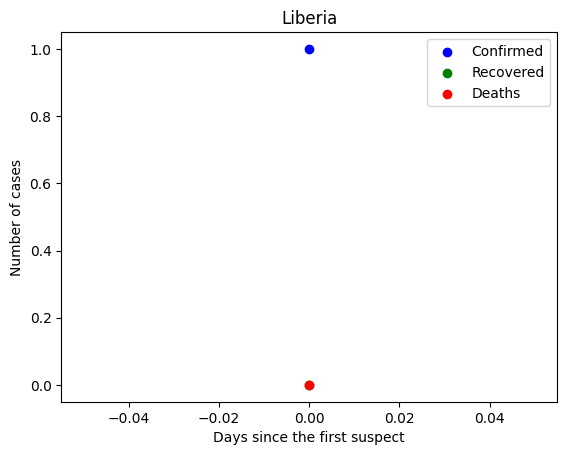

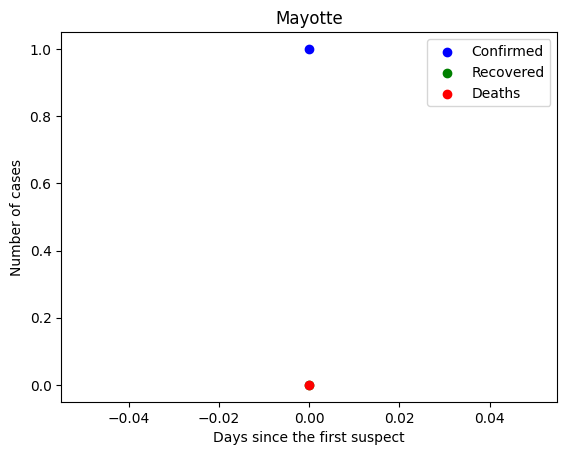

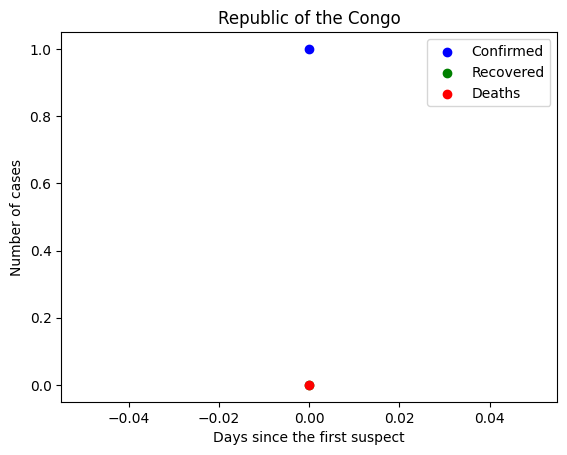

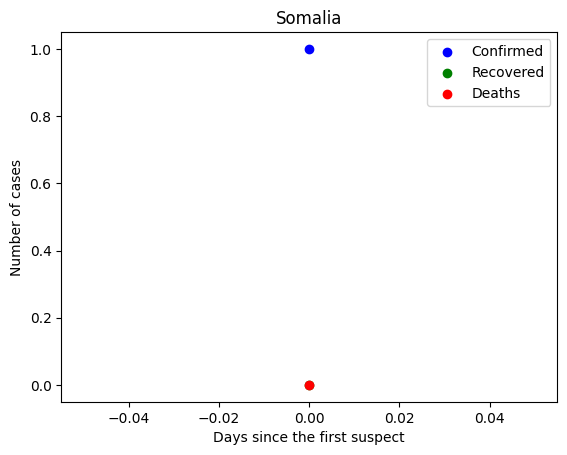

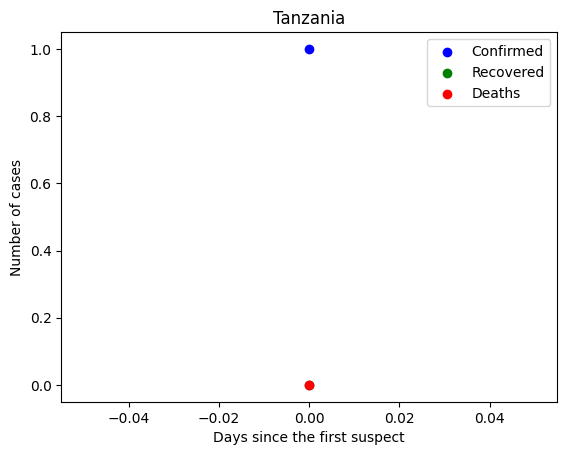

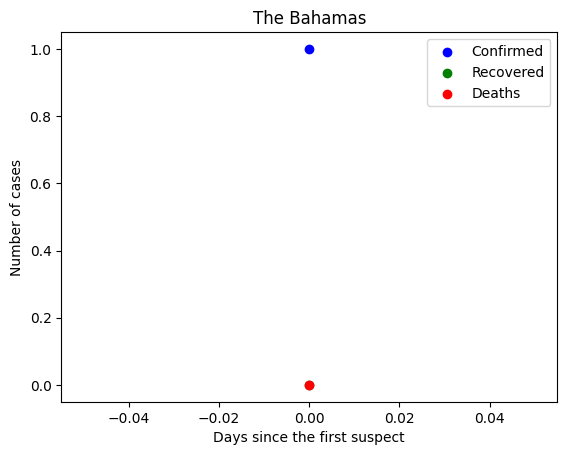

In [37]:
for idx in range(0,len(countries)):
    C = df2[df2['Country']==countries[idx]].reset_index()
    plt.scatter(np.arange(0,len(C)),C['Confirmed'],color='blue',label='Confirmed')
    plt.scatter(np.arange(0,len(C)),C['Recovered'],color='green',label='Recovered')
    plt.scatter(np.arange(0,len(C)),C['Deaths'],color='red',label='Deaths')
    plt.title(countries[idx])
    plt.xlabel('Days since the first suspect')
    plt.ylabel('Number of cases')
    plt.legend()
    plt.show() 

In [39]:
df4=df2.groupby(['Date'])[['Date','Confirmed','Deaths','Recovered']].sum().reset_index()

/var/folders/w3/ktvr1fsx4vzf522j4ttzycj40000gn/T/ipykernel_44874/2696133032.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df4=df2.groupby(['Date'])[['Date','Confirmed','Deaths','Recovered']].sum().reset_index()


In [40]:
df4

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,653,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1438,42,39
4,2020-01-26,2118,56,52
5,2020-01-27,2927,82,61
6,2020-01-28,5578,131,107
7,2020-01-29,6165,133,126
8,2020-01-30,8235,171,143
9,2020-01-31,9925,213,222


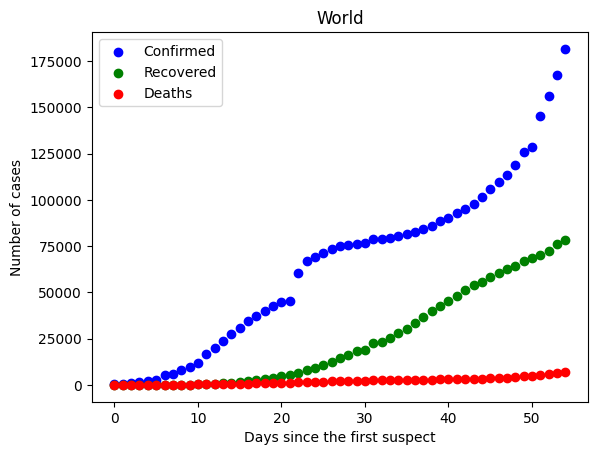

In [42]:
C=df4
plt.scatter(np.arange(0,len(C)),C['Confirmed'],color='blue',label='Confirmed')
plt.scatter(np.arange(0,len(C)),C['Recovered'],color='green',label='Recovered')
plt.scatter(np.arange(0,len(C)),C['Deaths'],color='red',label='Deaths')
plt.title('World data')
plt.xlabel('Days since the first suspect')
plt.ylabel('Number of cases')
plt.legend()
plt.show()
